### Lab 2

Yumol, Dianne

In [51]:
import os, math, random, warnings
from typing import Tuple
import numpy as np, math, matplotlib.pyplot as plt, time, warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.transforms import Bbox

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, confusion_matrix, classification_report, f1_score
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10,5)

warnings.filterwarnings("ignore")
random.seed(42); np.random.seed(42); torch.manual_seed(42)

DATA_DIR = "./data"    
TICKER = "IBM_2006-01-01_to_2018-01-01"               
FEATURE_COL = "Close"        
WINDOW_SIZE = 20
STRIDE = 1
NUM_OUTPUTS = 1
BATCH_SIZE = 64
LR = 1e-3
EPOCHS_REG = 50
EPOCHS_CLASS = 40
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FORECAST_STEPS = 30
MC_DROPOUT_SAMPLES = 50
TRIPLE_UPPER = 0.02
TRIPLE_LOWER = -0.02
TRIPLE_HORIZON = 5
TECH_HORIZON = 5
RSI_PERIOD = 14

def load_ticker_csv(ticker: str, data_dir: str = DATA_DIR) -> pd.DataFrame:
    path = os.path.join(data_dir, f"{ticker}.csv")
    if not os.path.exists(path):
        raise FileNotFoundError(f"{path} not found. Place CSVs into {data_dir}")
    df = pd.read_csv(path, parse_dates=['Date'], index_col='Date').sort_index()
    return df

df = load_ticker_csv(TICKER)
series = df[FEATURE_COL].astype(float).fillna(method='ffill').values
dates = df.index
print(f"Loaded {TICKER} with {len(series)} rows. Feature: {FEATURE_COL}")

Loaded IBM_2006-01-01_to_2018-01-01 with 3020 rows. Feature: Close


In [52]:
class TimeSeriesDataset(Dataset):
    def __init__(self, series: np.ndarray, window_size: int, num_outputs: int = 1, stride: int = 1, scaler: StandardScaler = None):
        self.series = np.asarray(series, dtype=float)
        self.window_size = window_size
        self.num_outputs = num_outputs
        self.stride = stride
        self.indices = []
        n = len(self.series)
        i = 0
        while i + window_size + num_outputs <= n:
            self.indices.append(i)
            i += stride
        if scaler is None:
            self.scaler = StandardScaler()
            self.scaler.fit(self.series.reshape(-1,1))
        else:
            self.scaler = scaler

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]
        x = self.series[i:i+self.window_size].reshape(-1,1)
        y = self.series[i+self.window_size: i+self.window_size+self.num_outputs].reshape(-1,1)
        x = self.scaler.transform(x).reshape(-1)
        y = self.scaler.transform(y).reshape(-1)
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

dataset = TimeSeriesDataset(series, WINDOW_SIZE, NUM_OUTPUTS, STRIDE)
n_total = len(dataset)
n_train = int(0.7 * n_total)
n_val = n_total - n_train
train_ds, val_ds = random_split(dataset, [n_train, n_val], generator=torch.Generator().manual_seed(42))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
print("Dataset sizes -> total:", n_total, "train:", n_train, "val:", n_val)

Dataset sizes -> total: 3000 train: 2100 val: 900


In [53]:
class MLPRegression(nn.Module):
    def __init__(self, input_size, hidden_sizes=[128,64], output_size=1, dropout=0.2):
        super().__init__()
        layers=[]
        prev=input_size
        for hs in hidden_sizes:
            layers.append(nn.Linear(prev, hs)); layers.append(nn.ReLU()); layers.append(nn.Dropout(dropout))
            prev=hs
        layers.append(nn.Linear(prev, output_size))  # NO output activation
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

model = MLPRegression(input_size=WINDOW_SIZE, hidden_sizes=[128,64], output_size=NUM_OUTPUTS, dropout=0.2).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

def train_model(model, train_loader, val_loader, epochs=EPOCHS_REG):
    train_losses=[]; val_losses=[]
    for ep in range(epochs):
        model.train()
        total=0; cnt=0
        for xb,yb in train_loader:
            xb=xb.to(DEVICE); yb=yb.to(DEVICE)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out.view(yb.shape), yb)
            loss.backward(); optimizer.step()
            total += loss.item() * xb.size(0); cnt += xb.size(0)
        train_losses.append(total/cnt)
        # validation
        model.eval()
        vtotal=0; vcnt=0
        with torch.no_grad():
            for xb,yb in val_loader:
                xb=xb.to(DEVICE); yb=yb.to(DEVICE)
                out = model(xb)
                loss = criterion(out.view(yb.shape), yb)
                vtotal += loss.item()*xb.size(0); vcnt+=xb.size(0)
        val_losses.append(vtotal/vcnt)
        if (ep+1)%10==0 or ep==0:
            print(f"Epoch {ep+1}/{epochs} train_loss={train_losses[-1]:.6f} val_loss={val_losses[-1]:.6f}")
    return train_losses, val_losses

print("Training regression MLP...")
train_losses, val_losses = train_model(model, train_loader, val_loader, epochs=EPOCHS_REG)


Training regression MLP...
Epoch 1/50 train_loss=0.187070 val_loss=0.033161
Epoch 10/50 train_loss=0.020725 val_loss=0.008988
Epoch 20/50 train_loss=0.017032 val_loss=0.005672
Epoch 30/50 train_loss=0.015945 val_loss=0.004627
Epoch 40/50 train_loss=0.016956 val_loss=0.004097
Epoch 50/50 train_loss=0.016103 val_loss=0.003679


In [54]:
def predict_on_loader(model, loader):
    model.eval()
    preds=[]; truths=[]
    with torch.no_grad():
        for xb,yb in loader:
            xb=xb.to(DEVICE)
            out = model(xb).cpu().numpy()
            preds.append(out); truths.append(yb.numpy())
    preds = np.vstack(preds).reshape(-1, NUM_OUTPUTS)
    truths = np.vstack(truths).reshape(-1, NUM_OUTPUTS)
    return preds, truths

val_preds_scaled, val_truths_scaled = predict_on_loader(model, val_loader)
scaler = dataset.scaler
val_preds = scaler.inverse_transform(val_preds_scaled.reshape(-1,1)).reshape(-1, NUM_OUTPUTS)
val_truths = scaler.inverse_transform(val_truths_scaled.reshape(-1,1)).reshape(-1, NUM_OUTPUTS)
rmse_one_step = math.sqrt(mean_squared_error(val_truths, val_preds))
print("Validation RMSE (one-step):", rmse_one_step)


Validation RMSE (one-step): 2.276048347469159


In [55]:
last_window = series[-WINDOW_SIZE:].reshape(-1,1)
last_window_scaled = scaler.transform(last_window).reshape(-1)  # scaled 1D

# Vanilla recursive forecast
def recursive_forecast_vanilla(model, start_scaled, steps, scaler):
    model.eval()
    x = start_scaled.copy()
    preds = []
    with torch.no_grad():
        for _ in range(steps):
            xb = torch.tensor(x.reshape(1,-1), dtype=torch.float32).to(DEVICE)
            out = model(xb).cpu().numpy().reshape(-1)[0]
            preds.append(out)
            x = np.roll(x, -1)
            x[-1] = out
    preds = np.array(preds).reshape(-1,1)
    return scaler.inverse_transform(preds).reshape(-1)

vanilla_preds = recursive_forecast_vanilla(model, last_window_scaled, FORECAST_STEPS, scaler)


In [56]:
# Residual-bootstrap (Method 1): build residuals from validation set in original units
residuals = (val_truths.reshape(-1) - val_preds.reshape(-1))
def residual_bootstrap_paths(model, start_scaled, steps, scaler, residuals, n_paths=30):
    paths=[]
    for _ in range(n_paths):
        x = start_scaled.copy()
        path=[]
        for __ in range(steps):
            xb = torch.tensor(x.reshape(1,-1), dtype=torch.float32).to(DEVICE)
            with torch.no_grad():
                out_scaled = model(xb).cpu().numpy().reshape(-1)[0]
            out_orig = scaler.inverse_transform(np.array([[out_scaled]])).reshape(-1)[0]
            sampled = np.random.choice(residuals)
            noisy_out_orig = out_orig + sampled
            noisy_out_scaled = scaler.transform(np.array([[noisy_out_orig]])).reshape(-1)[0]
            path.append(noisy_out_orig)
            x = np.roll(x, -1)
            x[-1] = noisy_out_scaled
        paths.append(np.array(path))
    return np.stack(paths, axis=0)

rb_paths = residual_bootstrap_paths(model, last_window_scaled, FORECAST_STEPS, scaler, residuals, n_paths=30)
rb_mean = rb_paths.mean(axis=0)


In [57]:
# MC Dropout (enable dropout at inference by model.train(), but we avoid BatchNorm in architecture)
def mc_dropout_forecast(model, start_scaled, steps, scaler, samples=MC_DROPOUT_SAMPLES):
    x = start_scaled.copy()
    mean_path = []
    for _ in range(steps):
        preds_step=[]
        for t in range(samples):
            model.train()  # enable dropout
            xb = torch.tensor(x.reshape(1,-1), dtype=torch.float32).to(DEVICE)
            with torch.no_grad():
                out = model(xb).cpu().numpy().reshape(-1)[0]
            preds_step.append(out)
        preds_step = np.array(preds_step)
        mean_scaled = preds_step.mean()
        mean_orig = scaler.inverse_transform(np.array([[mean_scaled]])).reshape(-1)[0]
        mean_path.append(mean_orig)
        x = np.roll(x, -1)
        x[-1] = mean_scaled
    return np.array(mean_path)

mc_dropout_path = mc_dropout_forecast(model, last_window_scaled, FORECAST_STEPS, scaler, samples=MC_DROPOUT_SAMPLES)


In [58]:
# Build windows (unscaled) and scale them for GP training
def build_window_arrays(series: np.ndarray, window_size: int, stride: int = 1):
    X=[]; y=[]
    n=len(series)
    i=0
    while i + window_size < n:
        X.append(series[i:i+window_size].reshape(-1))
        y.append(series[i+window_size])
        i += stride
    return np.array(X), np.array(y)

X_windows, y_next = build_window_arrays(series, WINDOW_SIZE, STRIDE)
value_scaler = StandardScaler().fit(series.reshape(-1,1))
X_scaled = value_scaler.transform(X_windows.reshape(-1,1)).reshape(X_windows.shape)
y_scaled = value_scaler.transform(y_next.reshape(-1,1)).reshape(-1)

# Train GP: kernel = C * RBF + White
kernel = C(1.0, (1e-3,1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-3,1e3)) + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-8,1e1))
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.0, normalize_y=True, n_restarts_optimizer=3)
print("Training GP for uncertainty propagation...")
gp.fit(X_scaled, y_scaled)
print("Trained GP kernel:", gp.kernel_)

# helper unpack
X_train = gp.X_train_
alpha = gp.alpha_.reshape(-1)   # (n_train,)
# try to read kernel params: const and length-scale
def _unpack(gp):
    k = gp.kernel_
    # attempt to handle (C * RBF) + White formatting
    try:
        const_val = float(k.k1.constant_value)
        length_scale = np.atleast_1d(k.k1.k2.length_scale)[0]
    except Exception:
        const_val = 1.0
        length_scale = 1.0
    return const_val, float(length_scale)
const_k, lscale = _unpack(gp)

# rbf kernel helper
def rbf_k_and_diff(x, Xref, const, l):
    diff = (x.reshape(1,-1) - Xref)  # (n_ref, d)
    sq = np.sum(diff**2, axis=1)
    k = const * np.exp(-0.5 * sq / (l**2))
    return k, diff

def gp_mean_and_std(x):
    m, std = gp.predict(x.reshape(1,-1), return_std=True)
    return float(m[0]), float(std[0])

def gp_mean_grad(x):
    k_vec, diff = rbf_k_and_diff(x, X_train, const_k, lscale)  # (n_train,), (n_train,d)
    # gradient of k_i wrt x: k_i * (-(x - x_i)/l^2)
    dkdx = (k_vec[:,None] * ( - diff / (lscale**2) ))  # (n_train, d)
    grad = (alpha.reshape(-1,1) * dkdx).sum(axis=0)   # (d,)
    return grad

def gp_uncertainty_propagation_forecast(gp, start_mu_scaled, start_Sigma_scaled, steps, scaler):
    mu = start_mu_scaled.copy()
    Sigma = start_Sigma_scaled.copy()  # (d,d)
    d = mu.shape[0]
    means_orig=[]; stds_orig=[]
    y_std = float(scaler.scale_[0])  # to convert scaled var to original units
    for t in range(steps):
        m_scaled, model_std = gp_mean_and_std(mu)
        model_var = model_std**2
        grad = gp_mean_grad(mu)
        var_input = float(grad.dot(Sigma.dot(grad)))
        total_var_scaled = model_var + var_input
        mean_orig = scaler.inverse_transform(np.array([[m_scaled]])).reshape(-1)[0]
        std_orig = math.sqrt(total_var_scaled) * y_std
        means_orig.append(mean_orig); stds_orig.append(std_orig)
        # cross-covariance Cov(f, x) ≈ Sigma @ grad
        cov_fx = Sigma.dot(grad)
        # roll mu and Sigma
        mu = np.roll(mu, -1); mu[-1] = m_scaled
        Sigma_new = np.zeros_like(Sigma)
        if d > 1:
            Sigma_new[:-1, :-1] = Sigma[1:, 1:]
            Sigma_new[:-1, -1] = cov_fx[1:]
            Sigma_new[-1, :-1] = cov_fx[1:]
        Sigma_new[-1, -1] = total_var_scaled
        Sigma = Sigma_new
    return np.array(means_orig), np.array(stds_orig)

# prepare start mu and Sigma (deterministic start)
last_window = series[-WINDOW_SIZE:].reshape(-1,1)
start_mu_scaled = value_scaler.transform(last_window.reshape(-1,1)).reshape(-1)
start_Sigma_scaled = np.zeros((WINDOW_SIZE, WINDOW_SIZE))
gp_means, gp_stds = gp_uncertainty_propagation_forecast(gp, start_mu_scaled, start_Sigma_scaled, FORECAST_STEPS, value_scaler)


Training GP for uncertainty propagation...
Trained GP kernel: 31.6**2 * RBF(length_scale=156) + WhiteKernel(noise_level=0.0025)


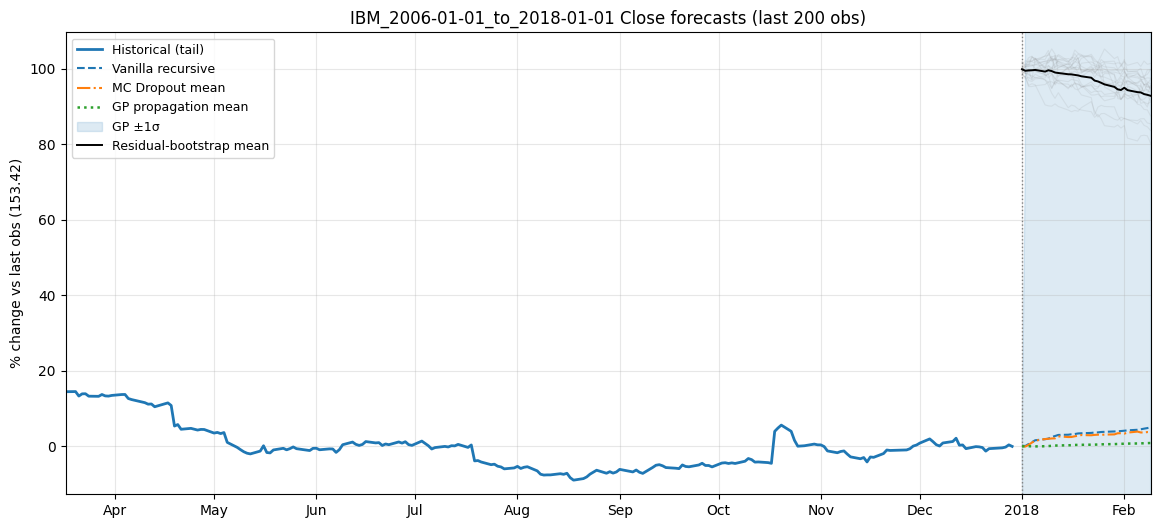

In [59]:
plot_tail = 200               
bootstrap_plot_n = 20         
use_percent_change = True     
clip_percentiles = (1, 99)    
inset_bbox = [0.65, 0.5, 0.3, 0.35]  

# infer freq for future dates; fallback to business day
freq = pd.infer_freq(dates)
if freq is None:
    freq = 'B'  # business day
future_dates = pd.date_range(start=dates[-1], periods=len(vanilla_preds)+1, freq=freq)[1:]

# prepare historical tail (with dates)
tail_idx = dates[-plot_tail:]
tail_vals = series[-plot_tail:]

# Build arrays for plotting (either absolute or percent change)
if use_percent_change:
    last_obs = float(series[-1])
    # historical percent change relative to last observed value
    hist_plot = (tail_vals / last_obs - 1.0) * 100.0
    vanilla_plot = (vanilla_preds / last_obs - 1.0) * 100.0
    mc_plot = (mc_dropout_path / last_obs - 1.0) * 100.0
    gp_plot = (gp_means / last_obs - 1.0) * 100.0
    gp_std_plot = (gp_stds / last_obs) * 100.0  # approx conversion for band
    rb_plot = rb_paths / last_obs * 100.0
    y_label = f"% change vs last obs ({last_obs:.2f})"
else:
    hist_plot = tail_vals
    vanilla_plot = vanilla_preds
    mc_plot = mc_dropout_path
    gp_plot = gp_means
    gp_std_plot = gp_stds
    rb_plot = rb_paths
    y_label = FEATURE_COL

# combine values to compute percentile-based y-limits
combined = np.concatenate([
    hist_plot,
    vanilla_plot,
    mc_plot,
    gp_plot,
    rb_plot.flatten()
])
ymin, ymax = np.percentile(combined, clip_percentiles)
# add small margin
yrange = ymax - ymin
ymin -= 0.05*yrange
ymax += 0.05*yrange

# ---------- Main figure ----------
fig, ax = plt.subplots(figsize=(14,6))

# historical line (tail)
ax.plot(tail_idx, hist_plot, label='Historical (tail)', linewidth=2, color='tab:blue')

# forecast start marker
forecast_start_date = future_dates[0]
ax.axvline(forecast_start_date, color='gray', linestyle=':', linewidth=1)

# vanilla forecast
ax.plot(future_dates, vanilla_plot, label='Vanilla recursive', linestyle='--', linewidth=1.5)

# MC Dropout mean
ax.plot(future_dates, mc_plot, label='MC Dropout mean', linestyle='-.', linewidth=1.5)

# GP mean + ±1σ band
ax.plot(future_dates, gp_plot, label='GP propagation mean', linestyle=':', linewidth=1.8)
ax.fill_between(future_dates,
                gp_plot - gp_std_plot,
                gp_plot + gp_std_plot,
                color='tab:blue', alpha=0.15, label='GP ±1σ')

# Residual-bootstrap ensemble (thin & faded), and mean
n_boot = min(bootstrap_plot_n, rb_plot.shape[0])
for i in range(n_boot):
    ax.plot(future_dates, rb_plot[i], color='gray', linewidth=0.8, alpha=0.12)
ax.plot(future_dates, rb_plot.mean(axis=0), label='Residual-bootstrap mean', color='black', linewidth=1.4)

# cosmetics
ax.set_xlim(tail_idx[0], future_dates[-1])
ax.set_ylim(ymin, ymax)
ax.set_title(f"{TICKER} {FEATURE_COL} forecasts (last {plot_tail} obs)")
ax.set_ylabel(y_label)
ax.grid(alpha=0.3)
ax.legend(loc='upper left', fontsize=9)

# format x-axis dates nicely
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.xticks(rotation=0)

plt.show()

In [60]:
# Triple Barrier labeling
def triple_barrier_labels(prices: pd.Series, upper=TRIPLE_UPPER, lower=TRIPLE_LOWER, horizon=TRIPLE_HORIZON):
    p = prices.values
    n = len(p)
    labels = np.full(n, np.nan)
    for t in range(n):
        end = min(n, t + horizon + 1)
        base = p[t]
        hit_label = 0
        for j in range(t+1, end):
            ret = (p[j] / base) - 1.0
            if ret >= upper:
                hit_label = 1
                break
            if ret <= lower:
                hit_label = -1
                break
        labels[t] = hit_label
    return pd.Series(labels, index=prices.index)

prices_series = pd.Series(series, index=dates)
triple_labels = triple_barrier_labels(prices_series)
print("Triple barrier counts (incl NaN):")
print(triple_labels.value_counts(dropna=False))


Triple barrier counts (incl NaN):
 0.0    1423
 1.0     837
-1.0     760
Name: count, dtype: int64


In [61]:
# Technical indicators (RSI, MACD, MA50/MA200) and labeling 
def compute_rsi(series: pd.Series, period=RSI_PERIOD):
    delta = series.diff()
    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)
    roll_up = up.ewm(alpha=1/period, adjust=False).mean()
    roll_down = down.ewm(alpha=1/period, adjust=False).mean()
    rs = roll_up / (roll_down + 1e-12)
    rsi = 100 - (100 / (1 + rs))
    return rsi

def compute_macd(series: pd.Series, n_fast=12, n_slow=26, n_signal=9):
    ema_fast = series.ewm(span=n_fast, adjust=False).mean()
    ema_slow = series.ewm(span=n_slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    signal = macd.ewm(span=n_signal, adjust=False).mean()
    hist = macd - signal
    return macd, signal, hist

df['RSI'] = compute_rsi(prices_series)
df['MACD'], df['MACD_signal'], df['MACD_hist'] = compute_macd(prices_series)
df['MA50'] = prices_series.rolling(window=50, min_periods=1).mean()
df['MA200'] = prices_series.rolling(window=200, min_periods=1).mean()

def cross_up(a,b):
    diff = a - b
    prev = diff.shift(1)
    return (prev < 0) & (diff > 0)
def cross_down(a,b):
    diff = a - b
    prev = diff.shift(1)
    return (prev > 0) & (diff < 0)

df['MACD_cross_up'] = cross_up(df['MACD'], df['MACD_signal'])
df['MACD_cross_down'] = cross_down(df['MACD'], df['MACD_signal'])
df['MA_golden'] = cross_up(df['MA50'], df['MA200'])
df['MA_death'] = cross_down(df['MA50'], df['MA200'])

def technical_labels(df: pd.DataFrame, rsi_low=30, rsi_high=70, lookahead=TECH_HORIZON):
    n = len(df)
    labs = np.zeros(n, dtype=int)
    for i in range(n):
        rsi = df['RSI'].iat[i]
        if np.isnan(rsi):
            labs[i] = 0; continue
        if rsi < rsi_low:
            labs[i] = 1; continue
        if rsi > rsi_high:
            labs[i] = -1; continue
        end = min(n, i + lookahead + 1)
        if df['MACD_cross_up'].iloc[i+1:end].any() or df['MA_golden'].iloc[i+1:end].any():
            labs[i] = 1; continue
        if df['MACD_cross_down'].iloc[i+1:end].any() or df['MA_death'].iloc[i+1:end].any():
            labs[i] = -1; continue
        labs[i] = 0
    return pd.Series(labs, index=df.index)

tech_labels = technical_labels(df)
print("Technical labels distribution:")
print(tech_labels.value_counts())


Technical labels distribution:
 0    1681
 1     738
-1     601
Name: count, dtype: int64


In [62]:
# Create sliding-window (X,y) for classification, map {-1,0,1} -> {0,1,2}
def windows_from_series(series: pd.Series, labels: pd.Series, window_size: int, stride: int = 1):
    X=[]; y=[]; idxs=[]
    values=series.values; labs=labels.values; n=len(values)
    i=0
    while i + window_size <= n - 1:
        lab_idx = i + window_size - 1
        lab = labs[lab_idx]
        if np.isnan(lab):
            i += stride; continue
        win = values[i:i+window_size]
        mapped = { -1:0, 0:1, 1:2 }[int(lab)]
        X.append(win); y.append(mapped); idxs.append(series.index[lab_idx])
        i += stride
    return np.array(X), np.array(y), idxs

X_triple, y_triple, _ = windows_from_series(prices_series, triple_labels, WINDOW_SIZE, STRIDE)
X_tech, y_tech, _ = windows_from_series(prices_series, tech_labels, WINDOW_SIZE, STRIDE)
print("Triple dataset:", X_triple.shape, "class counts:", np.bincount(y_triple))
print("Tech dataset:", X_tech.shape, "class counts:", np.bincount(y_tech))


Triple dataset: (3000, 20) class counts: [ 753 1413  834]
Tech dataset: (3000, 20) class counts: [ 596 1668  736]


In [63]:
class SimpleWindowDataset(Dataset):
    def __init__(self, X, y, scaler=None):
        self.Xraw = X.astype(float)
        self.y = y.astype(int)
        if scaler is None:
            self.scaler = StandardScaler()
            self.scaler.fit(self.Xraw.reshape(-1,1))
        else:
            self.scaler = scaler
        self.X = self.scaler.transform(self.Xraw.reshape(-1,1)).reshape(self.Xraw.shape)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return torch.tensor(self.X[i], dtype=torch.float32), torch.tensor(self.y[i], dtype=torch.long)

class MLPClassifier(nn.Module):
    def __init__(self, input_size, hidden_sizes=[128,64], num_classes=3, dropout=0.2):
        super().__init__()
        layers=[]
        prev=input_size
        for hs in hidden_sizes:
            layers.append(nn.Linear(prev, hs)); layers.append(nn.ReLU()); layers.append(nn.Dropout(dropout))
            prev=hs
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)
    def forward(self,x):
        return self.net(x)

def train_and_eval_classifier(X, y, epochs=EPOCHS_CLASS, hidden=[128,64]):
    ds = SimpleWindowDataset(X, y)
    n_total = len(ds)
    n_train = int(0.7 * n_total)
    n_val = n_total - n_train
    train_ds, val_ds = random_split(ds, [n_train, n_val], generator=torch.Generator().manual_seed(42))
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    model = MLPClassifier(input_size=X.shape[1], hidden_sizes=hidden, num_classes=len(np.unique(y))).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()
    for ep in range(epochs):
        model.train()
        for xb,yb in train_loader:
            xb=xb.to(DEVICE); yb=yb.to(DEVICE)
            opt.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            loss.backward(); opt.step()
    # eval
    model.eval()
    y_true=[]; y_pred=[]
    with torch.no_grad():
        for xb,yb in val_loader:
            xb=xb.to(DEVICE)
            out = model(xb)
            preds = torch.argmax(out, dim=1).cpu().numpy()
            y_pred.extend(preds.tolist())
            y_true.extend(yb.numpy().tolist())
    y_true = np.array(y_true); y_pred = np.array(y_pred)
    return model, ds, y_true, y_pred

# Train triple classifier
print("\nTraining triple-barrier classifier...")
clf_triple, ds_triple, ytr_true, ytr_pred = train_and_eval_classifier(X_triple, y_triple, epochs=EPOCHS_CLASS, hidden=[128,64])
print("Triple-barrier classification report:")
print(classification_report(ytr_true, ytr_pred, digits=4, target_names=["-1 (sell)->0","0 (hold)->1","+1 (buy)->2"]))
print("Confusion:\n", confusion_matrix(ytr_true, ytr_pred))
print("F1 macro:", f1_score(ytr_true, ytr_pred, average='macro'))

# Train technical classifier
print("\nTraining technical-indicator classifier...")
clf_tech, ds_tech, yte_true, yte_pred = train_and_eval_classifier(X_tech, y_tech, epochs=EPOCHS_CLASS, hidden=[128,64])
print("Technical classification report:")
print(classification_report(yte_true, yte_pred, digits=4, target_names=["-1 (sell)->0","0 (hold)->1","+1 (buy)->2"]))
print("Confusion:\n", confusion_matrix(yte_true, yte_pred))
print("F1 macro:", f1_score(yte_true, yte_pred, average='macro'))


Training triple-barrier classifier...
Triple-barrier classification report:
              precision    recall  f1-score   support

-1 (sell)->0     0.4255    0.0939    0.1538       213
 0 (hold)->1     0.4988    0.9459    0.6531       425
 +1 (buy)->2     0.4468    0.0802    0.1359       262

    accuracy                         0.4922       900
   macro avg     0.4570    0.3733    0.3143       900
weighted avg     0.4663    0.4922    0.3844       900

Confusion:
 [[ 20 182  11]
 [  8 402  15]
 [ 19 222  21]]
F1 macro: 0.3142986741765854

Training technical-indicator classifier...
Technical classification report:
              precision    recall  f1-score   support

-1 (sell)->0     0.4530    0.2978    0.3593       178
 0 (hold)->1     0.5785    0.8180    0.6777       500
 +1 (buy)->2     0.5658    0.1937    0.2886       222

    accuracy                         0.5611       900
   macro avg     0.5324    0.4365    0.4419       900
weighted avg     0.5505    0.5611    0.5188       90

### Feature Importance Ranking, Ablation Studies, etc.

In [64]:
warnings.filterwarnings("ignore")
random.seed(42); np.random.seed(42); torch.manual_seed(42)

WINDOW_SIZE = 20
STRIDE = 1
BATCH_SIZE = 64
EPOCHS_MLP = 20
EPOCHS_LSTM = 20
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RSI_PERIOD = 14
ROLL_VOL_WINDOW = 10

def load_df(ticker, data_dir=DATA_DIR):
    p = os.path.join(data_dir, f"{ticker}.csv")
    if not os.path.exists(p):
        raise FileNotFoundError(f"{p} not found. Put CSVs into {data_dir}")
    df = pd.read_csv(p, parse_dates=['Date'], index_col='Date').sort_index()
    return df

df = load_df(TICKER)
prices = df[FEATURE_COL].astype(float).fillna(method='ffill')
dates = df.index
print(f"Loaded {TICKER}: {len(prices)} rows")

def triple_barrier_labels(prices: pd.Series, upper=0.02, lower=-0.02, horizon=5):
    p = prices.values
    n = len(p)
    labels = np.full(n, np.nan)
    for t in range(n):
        end = min(n, t + horizon + 1)
        base = p[t]
        hit_label = 0
        for j in range(t+1, end):
            ret = (p[j] / base) - 1.0
            if ret >= upper:
                hit_label = 1
                break
            if ret <= lower:
                hit_label = -1
                break
        labels[t] = hit_label
    return pd.Series(labels, index=prices.index)

def compute_rsi(series: pd.Series, period=14):
    delta = series.diff()
    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)
    roll_up = up.ewm(alpha=1/period, adjust=False).mean()
    roll_down = down.ewm(alpha=1/period, adjust=False).mean()
    rs = roll_up / (roll_down + 1e-12)
    rsi = 100 - (100 / (1 + rs))
    return rsi

def compute_macd(series: pd.Series, n_fast=12, n_slow=26, n_signal=9):
    ema_fast = series.ewm(span=n_fast, adjust=False).mean()
    ema_slow = series.ewm(span=n_slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    signal = macd.ewm(span=n_signal, adjust=False).mean()
    hist = macd - signal
    return macd, signal, hist

def technical_labels(df: pd.DataFrame, rsi_low=30, rsi_high=70, lookahead=5):
    dfc = df.copy()
    dfc['RSI'] = compute_rsi(dfc['Close'])
    dfc['MACD'], dfc['MACD_signal'], dfc['MACD_hist'] = compute_macd(dfc['Close'])
    dfc['MA50'] = dfc['Close'].rolling(50, min_periods=1).mean()
    dfc['MA200'] = dfc['Close'].rolling(200, min_periods=1).mean()
    def cross_up(a,b):
        diff = a-b; prev = diff.shift(1)
        return (prev < 0) & (diff > 0)
    def cross_down(a,b):
        diff = a-b; prev = diff.shift(1)
        return (prev > 0) & (diff < 0)
    dfc['MACD_up'] = cross_up(dfc['MACD'], dfc['MACD_signal'])
    dfc['MACD_down'] = cross_down(dfc['MACD'], dfc['MACD_signal'])
    dfc['MA_golden'] = cross_up(dfc['MA50'], dfc['MA200'])
    dfc['MA_death'] = cross_down(dfc['MA50'], dfc['MA200'])
    n=len(dfc); labs = np.zeros(n, dtype=int)
    for i in range(n):
        rsi = dfc['RSI'].iat[i]
        if np.isnan(rsi):
            labs[i] = 0; continue
        if rsi < rsi_low:
            labs[i] = 1; continue
        if rsi > rsi_high:
            labs[i] = -1; continue
        end = min(n, i + lookahead + 1)
        if dfc['MACD_up'].iloc[i+1:end].any() or dfc['MA_golden'].iloc[i+1:end].any():
            labs[i] = 1; continue
        if dfc['MACD_down'].iloc[i+1:end].any() or dfc['MA_death'].iloc[i+1:end].any():
            labs[i] = -1; continue
        labs[i] = 0
    return pd.Series(labs, index=df.index)

# compute labels
triple_labels = triple_barrier_labels(prices, upper=0.02, lower=-0.02, horizon=5)
tech_labels = technical_labels(df)

def make_features_df(df: pd.DataFrame, rsi_period=RSI_PERIOD, roll_vol=ROLL_VOL_WINDOW):
    out = pd.DataFrame(index=df.index)
    out['close'] = df['Close'].astype(float)
    out['logret'] = np.log(out['close']).diff().fillna(0.0)
    out['rsi'] = compute_rsi(out['close'], period=rsi_period).fillna(method='bfill').fillna(50.0)
    out['vol'] = out['logret'].rolling(window=roll_vol, min_periods=1).std().fillna(0.0)
    return out

feat_df = make_features_df(df)
features_array = feat_df.values  # shape (n_dates, n_features)
n_features = features_array.shape[1]
print("Feature columns:", feat_df.columns.tolist())

def build_windows_from_features(features: np.ndarray, labels: pd.Series, window_size: int, stride: int = 1):
    X_seq = []   # (n_windows, window_size, n_features)
    y = []
    idxs = []
    vals = features
    labs = labels.values
    n = len(vals)
    i = 0
    while i + window_size <= n - 1:
        lab_idx = i + window_size - 1  # align label to last index in window
        lab = labs[lab_idx]
        if np.isnan(lab):
            i += stride; continue
        win = vals[i:i+window_size]
        mapped = { -1:0, 0:1, 1:2 }[int(lab)]
        X_seq.append(win)
        y.append(mapped)
        idxs.append(lab_idx)
        i += stride
    return np.array(X_seq), np.array(y), np.array(idxs)

# build windows for both label types
X_triple_seq, y_triple, idx_triple = build_windows_from_features(features_array, triple_labels, WINDOW_SIZE, STRIDE)
X_tech_seq, y_tech, idx_tech = build_windows_from_features(features_array, tech_labels, WINDOW_SIZE, STRIDE)
print("Triple windows:", X_triple_seq.shape, "class counts:", np.bincount(y_triple))
print("Tech windows:", X_tech_seq.shape, "class counts:", np.bincount(y_tech))

def train_val_split_by_index(X, y, split_frac=0.7):
    n = len(X)
    n_train = int(split_frac * n)
    train_X = X[:n_train]; train_y = y[:n_train]
    val_X = X[n_train:]; val_y = y[n_train:]
    return train_X, train_y, val_X, val_y

class FlattenWindowDataset(Dataset):
    def __init__(self, X_seq, y):
        # flatten windows into (window_size * n_features) vectors
        self.X = X_seq.reshape(X_seq.shape[0], -1).astype(np.float32)
        self.y = y.astype(np.int64)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return torch.tensor(self.X[i]), torch.tensor(self.y[i])

class SequenceWindowDataset(Dataset):
    def __init__(self, X_seq, y):
        # keep sequences as (time, features)
        self.X = X_seq.astype(np.float32)
        self.y = y.astype(np.int64)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return torch.tensor(self.X[i]), torch.tensor(self.y[i])

class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden=[128,64], n_classes=3, dropout=0.2):
        super().__init__()
        layers=[]
        prev=input_dim
        for h in hidden:
            layers.append(nn.Linear(prev,h)); layers.append(nn.ReLU()); layers.append(nn.Dropout(dropout))
            prev=h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)
    def forward(self,x): return self.net(x)

class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, n_classes=3, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, n_classes)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        # x: (batch, time, features)
        out, _ = self.lstm(x)
        last = out[:, -1, :]  # last timestep
        last = self.dropout(last)
        return self.fc(last)

def compute_class_weights(y_train):
    classes = np.unique(y_train)
    cw = compute_class_weight('balanced', classes=classes, y=y_train)
    # map to tensor in class index order (0,1,2)
    weights = np.ones(len(classes))
    for i,c in enumerate(classes):
        weights[c] = cw[i]
    return torch.tensor(weights, dtype=torch.float32)

def train_mlp(train_X, train_y, val_X, val_y, epochs=20, device=DEVICE):
    """
    Corrected train_mlp: fits StandardScaler on flattened training data,
    then transforms both train and validation using the same scaler.
    Accepts train_X either as (n, window, features) or already flattened (n, D).
    """
    # ----- Prepare flattened arrays -----
    if train_X.ndim == 3:
        n, w, f = train_X.shape
        train_flat = train_X.reshape(n, w * f)
        val_flat = val_X.reshape(val_X.shape[0], w * f)
    elif train_X.ndim == 2:
        train_flat = train_X.copy()
        val_flat = val_X.copy()
    else:
        raise ValueError("train_X must be 2D or 3D")

    # Debug prints to confirm shapes
    print("MLP: train_flat.shape =", train_flat.shape, "; val_flat.shape =", val_flat.shape)

    scaler = StandardScaler().fit(train_flat)   # fit on shape (n_train, flat_dim)
    train_scaled = scaler.transform(train_flat)
    val_scaled = scaler.transform(val_flat)

    # datasets & loaders (flattened)
    class FlattenWindowDataset(torch.utils.data.Dataset):
        def __init__(self, X, y):
            self.X = X.astype(np.float32)
            self.y = y.astype(np.int64)
        def __len__(self): return len(self.y)
        def __getitem__(self, i): return torch.tensor(self.X[i]), torch.tensor(self.y[i])

    ds_train = FlattenWindowDataset(train_scaled, train_y)
    ds_val = FlattenWindowDataset(val_scaled, val_y)
    loader_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=False)
    loader_val = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False)

    # compute class weights (map in case class labels are not contiguous)
    classes = np.unique(train_y)
    cw = compute_class_weight('balanced', classes=classes, y=train_y)
    # create weight vector aligned to class indices 0..C-1
    weight_vector = np.ones(len(classes), dtype=np.float32)
    for i, c in enumerate(classes):
        weight_vector[c] = cw[i]
    class_weights = torch.tensor(weight_vector).to(device)

    loss_fn = nn.CrossEntropyLoss(weight=class_weights)
    model = MLPClassifier(input_dim=train_scaled.shape[1], hidden=[128,64], n_classes=len(classes)).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)

    # training loop
    for ep in range(epochs):
        model.train()
        for xb, yb in loader_train:
            xb = xb.to(device); yb = yb.to(device)
            opt.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            loss.backward(); opt.step()

    # evaluation
    model.eval()
    y_true = []; y_pred = []
    with torch.no_grad():
        for xb, yb in loader_val:
            xb = xb.to(device)
            out = model(xb)
            preds = torch.argmax(out, dim=1).cpu().numpy()
            y_pred.extend(preds.tolist()); y_true.extend(yb.numpy().tolist())
    return model, scaler, np.array(y_true), np.array(y_pred)

def train_lstm(train_X, train_y, val_X, val_y, epochs=20, device=DEVICE):
    # train_X shape: (n, window, features)
    n_train, w, f = train_X.shape
    # scale per feature using scaler_fit on flattened training (stacked by feature)
    scaler = StandardScaler().fit(train_X.reshape(-1, f))
    train_scaled = scaler.transform(train_X.reshape(-1, f)).reshape(n_train, w, f)
    n_val = val_X.shape[0]
    val_scaled = scaler.transform(val_X.reshape(-1, f)).reshape(n_val, w, f)
    ds_train = SequenceWindowDataset(train_scaled, train_y)
    ds_val = SequenceWindowDataset(val_scaled, val_y)
    loader_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=False)
    loader_val = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False)
    class_weights = compute_class_weights(train_y).to(device)
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)
    model = LSTMClassifier(input_size=f, hidden_size=64, num_layers=1, n_classes=len(np.unique(train_y))).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    for ep in range(epochs):
        model.train()
        for xb,yb in loader_train:
            xb = xb.to(device); yb = yb.to(device)
            opt.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            loss.backward(); opt.step()
    model.eval()
    y_true=[]; y_pred=[]
    with torch.no_grad():
        for xb,yb in loader_val:
            xb = xb.to(device)
            out = model(xb)
            preds = torch.argmax(out, dim=1).cpu().numpy()
            y_pred.extend(preds.tolist()); y_true.extend(yb.numpy().tolist())
    return model, scaler, np.array(y_true), np.array(y_pred)

for label_name, (X_seq, y_all) in [('triple', (X_triple_seq, y_triple)), ('technical', (X_tech_seq, y_tech))]:
    print(f"Label set: {label_name} (mapped classes 0:-1(sell), 1:0(hold), 2:+1(buy))")
    print("Total windows:", len(X_seq))
    if len(X_seq) == 0:
        print("No windows available for this label set - skipping.")
        continue

    # split
    train_X, train_y, val_X, val_y = train_val_split_by_index(X_seq, y_all, split_frac=0.7)
    print("Train/Val sizes:", train_X.shape[0], "/", val_X.shape[0])
    print("Train class counts:", np.bincount(train_y))
    print("Val class counts:", np.bincount(val_y))

    # Class-weighted MLP on flattened features
    mlp_model, mlp_scaler, y_true_mlp, y_pred_mlp = train_mlp(train_X, train_y, val_X, val_y, epochs=EPOCHS_MLP, device=DEVICE)
    print("\n[MLP - class-weighted] Classification report:")
    print(classification_report(y_true_mlp, y_pred_mlp, digits=4, target_names=["sell(-1)->0","hold(0)->1","buy(+1)->2"]))
    print("Confusion matrix:\n", confusion_matrix(y_true_mlp, y_pred_mlp))
    print("Macro F1:", f1_score(y_true_mlp, y_pred_mlp, average='macro'))

    # (B) Feature-augmented LSTM
    lstm_model, lstm_scaler, y_true_lstm, y_pred_lstm = train_lstm(train_X, train_y, val_X, val_y, epochs=EPOCHS_LSTM, device=DEVICE)
    print("\n[LSTM - feature-augmented] Classification report:")
    print(classification_report(y_true_lstm, y_pred_lstm, digits=4, target_names=["sell(-1)->0","hold(0)->1","buy(+1)->2"]))
    print("Confusion matrix:\n", confusion_matrix(y_true_lstm, y_pred_lstm))
    print("Macro F1:", f1_score(y_true_lstm, y_pred_lstm, average='macro'))


Loaded IBM_2006-01-01_to_2018-01-01: 3020 rows
Feature columns: ['close', 'logret', 'rsi', 'vol']
Triple windows: (3000, 20, 4) class counts: [ 753 1413  834]
Tech windows: (3000, 20, 4) class counts: [ 596 1668  736]
Label set: triple (mapped classes 0:-1(sell), 1:0(hold), 2:+1(buy))
Total windows: 3000
Train/Val sizes: 2100 / 900
Train class counts: [539 915 646]
Val class counts: [214 498 188]
MLP: train_flat.shape = (2100, 80) ; val_flat.shape = (900, 80)

[MLP - class-weighted] Classification report:
              precision    recall  f1-score   support

 sell(-1)->0     0.2754    0.2150    0.2415       214
  hold(0)->1     0.6122    0.5040    0.5529       498
  buy(+1)->2     0.2260    0.3883    0.2857       188

    accuracy                         0.4111       900
   macro avg     0.3712    0.3691    0.3600       900
weighted avg     0.4515    0.4111    0.4230       900

Confusion matrix:
 [[ 46  89  79]
 [ 76 251 171]
 [ 45  70  73]]
Macro F1: 0.36001584603686654

[LSTM - feat

RMSE vs Horizon & Coverage (ensemble methods)
Number of eval windows: 150
Forecast ensembles computed for 150 windows in 97.3s


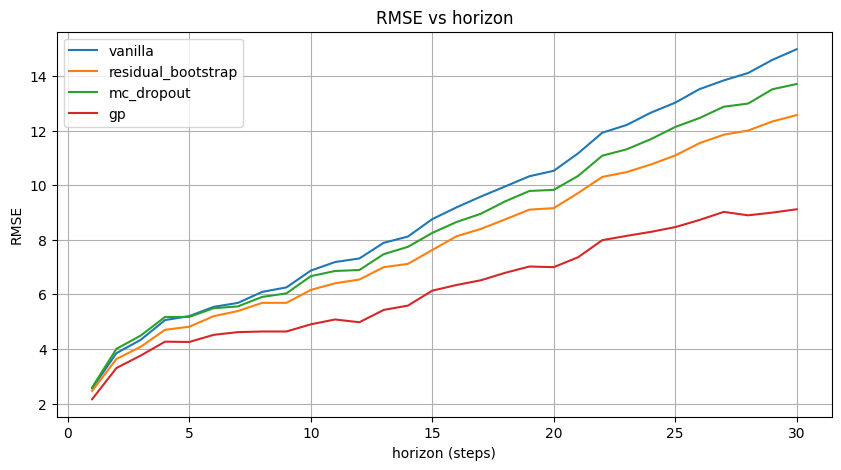


Coverage by method and nominal levels
  residual_bootstrap level=0.5: mean coverage across horizons (1..30) = 0.305
  residual_bootstrap level=0.8: mean coverage across horizons (1..30) = 0.532
  residual_bootstrap level=0.9: mean coverage across horizons (1..30) = 0.652
  residual_bootstrap level=0.95: mean coverage across horizons (1..30) = 0.727
  mc_dropout level=0.5: mean coverage across horizons (1..30) = 0.442
  mc_dropout level=0.8: mean coverage across horizons (1..30) = 0.727
  mc_dropout level=0.9: mean coverage across horizons (1..30) = 0.822
  mc_dropout level=0.95: mean coverage across horizons (1..30) = 0.867
  gp level=0.5: mean coverage across horizons (1..30) = 0.983
  gp level=0.8: mean coverage across horizons (1..30) = 0.993
  gp level=0.9: mean coverage across horizons (1..30) = 0.997
  gp level=0.95: mean coverage across horizons (1..30) = 0.998

CRPS (empirical) per method (mean across windows & horizons)
  residual_bootstrap: mean CRPS = 4.724473
  mc_dropout:

In [65]:
# RMSE/Coverage/Ablation/Class-weighted/Lite-backtest
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10,5)

EVAL_SAMPLES = 150        
HORIZON = 30              
MC_SAMPLES = 50          
RB_SAMPLES = 30           
GP_SAMPLES_FOR_CRPS = 100 
CALIB_LEVELS = [0.5, 0.8, 0.9, 0.95]

def safe_get(name):
    return globals().get(name, None)

def rmse(a,b): return math.sqrt(mean_squared_error(a,b))

def crps_empirical(y, samples):
    # approximate CRPS for single scalar y and array of samples s: CRPS = E|S - y| - 0.5 E|S - S'|
    # we'll vectorize: samples shape (n_samples,)
    s = np.asarray(samples)
    term1 = np.mean(np.abs(s - y))
    # pairwise absolute diffs mean:
    m = np.mean(np.abs(s[:,None] - s[None,:]))
    return term1 - 0.5 * m

def batch_crps_empirical(y_array, sample_matrix):
    # y_array shape (N,), sample_matrix shape (N, n_samples)
    res = []
    for i in range(len(y_array)):
        res.append(crps_empirical(y_array[i], sample_matrix[i]))
    return np.array(res)

# RMSE vs horizon & coverage for probabilistic methods
print("RMSE vs Horizon & Coverage (ensemble methods)")
# required objects: series, model (regression MLP), dataset (TimeSeriesDataset), scaler
series_arr = safe_get('series')
reg_model = safe_get('model')  # MLP regression
dataset_obj = safe_get('dataset') or safe_get('full_dataset')  # earlier named variants
scaler = safe_get('scaler') or (dataset_obj.scaler if dataset_obj is not None else None)
gp = safe_get('gp')
value_scaler = safe_get('value_scaler') or safe_get('dataset').scaler if safe_get('dataset') else None
residuals = safe_get('residuals')
rb_paths_global = safe_get('rb_paths')  # these were from forecasting only for last window; not per-window
mc_dropout_global = safe_get('mc_dropout_path')
vanilla_global = safe_get('vanilla_preds')

# If we do per-validation starting points, we need a validation dataset; try val_ds or val_dataset / val_loader
val_dataset = safe_get('val_dataset') or safe_get('val_ds') or safe_get('val_dataset') if False else safe_get('val_dataset')
# fallback: if earlier used random_split, try local variable train_ds/val_ds
if val_dataset is None:
    val_dataset = safe_get('val_ds') or safe_get('val_dataset') or safe_get('val_dataset_instance') or safe_get('val_ds_instance')
if val_dataset is None:
    # try get from variables train_ds/val_ds
    val_dataset = safe_get('val_ds') or safe_get('val_dataset') or safe_get('val_dataset_instance')

# if still None, try to create windows and take last N windows as evaluation starting points
def build_windows_from_series(series, window_size, stride=1):
    X=[]; idxs=[]
    n=len(series)
    i=0
    while i + window_size < n:
        X.append(series[i:i+window_size].reshape(-1))
        idxs.append(i)
        i += stride
    return np.array(X), np.array(idxs)

WINDOW_SIZE_local = globals().get('WINDOW_SIZE', None) or (dataset_obj.window_size if dataset_obj is not None and hasattr(dataset_obj,'window_size') else None)
if series_arr is None:
    print("ERROR: 'series' not found in workspace. Skipping RMSE/Coverage step.")
else:
    if val_dataset is None and WINDOW_SIZE_local is not None:
        X_windows_all, idxs_all = build_windows_from_series(series_arr, WINDOW_SIZE_local, stride=STRIDE if 'STRIDE' in globals() else 1)
        # use last EVAL_SAMPLES windows as evaluation starting points
        if len(X_windows_all) == 0:
            print("No windows found. Skipping.")
        else:
            eval_idxs = np.arange(max(0, len(X_windows_all)-EVAL_SAMPLES), len(X_windows_all))
            eval_windows = X_windows_all[eval_idxs]
            eval_start_positions = idxs_all[eval_idxs]  # start index of each window
    elif val_dataset is not None:
        # try to extract raw windows and starting indices from val_dataset (works if dataset returns unscaled arrays)
        try:
            eval_windows = []
            eval_start_positions = []
            # val_dataset may be a Subset -> get underlying dataset and indices
            if hasattr(val_dataset, 'dataset') and hasattr(val_dataset, 'indices'):
                base = val_dataset.dataset
                indices = val_dataset.indices[:EVAL_SAMPLES]
                for ii in indices:
                    x,_ = base[ii]
                    # base returns scaled? we want original unscaled window
                    # fallback: use dataset_obj to recover original window by index
                    eval_windows.append(x.numpy())
                    eval_start_positions.append(ii)
            else:
                # iterate first EVAL_SAMPLES
                cnt=0
                for xb, yb in val_dataset:
                    if cnt >= EVAL_SAMPLES: break
                    eval_windows.append(xb.numpy())
                    eval_start_positions.append(None)
                    cnt+=1
            eval_windows = np.array(eval_windows)
        except Exception as e:
            print("Could not extract eval windows from val_dataset (error)", e)
            eval_windows = None

    # Ensure we have eval_windows; if missing, skip
    if 'eval_windows' not in locals() or eval_windows is None:
        print("No evaluation windows available — skipping RMSE/Coverage.")
    else:
        n_eval = min(len(eval_windows), EVAL_SAMPLES)
        print("Number of eval windows:", n_eval)
        eval_windows = eval_windows[:n_eval]
        # Build ground-truth matrix for horizons 1..HORIZON
        n = len(series_arr)
        # For each window starting at pos p (we need the index of the last observed point)
        # If eval_start_positions contains window start index i, last observed index = i + WINDOW_SIZE_local -1.
        starts = []
        if isinstance(eval_start_positions[0], (int, np.integer)):
            for i in eval_start_positions[:n_eval]:
                if i is None:
                    starts.append(None)
                else:
                    starts.append(i + WINDOW_SIZE_local - 1)
        else:
            # unknown starts -> assume consecutive windows near end: align from last_window
            last_pos = n - 1
            starts = [n - WINDOW_SIZE_local - (n_eval - 1 - k) + WINDOW_SIZE_local -1 for k in range(n_eval)]
        # Create containers for forecast means and ensemble draws
        methods = ['vanilla', 'residual_bootstrap', 'mc_dropout', 'gp']
        preds_mean = {m: np.zeros((n_eval, HORIZON)) for m in methods}
        # store ensemble samples for coverage/crps where applicable
        ensemble_samples = {m: None for m in methods}  # will be dict of shape (n_eval, HORIZON, n_samples)
        start_time = time.time()

        # helper to run recursive forecast for one window using regression MLP
        def recursive_forecast_single(model, window_scaled, steps):
            model.eval()
            x = window_scaled.copy()
            out_list = []
            with torch.no_grad():
                for _ in range(steps):
                    xb = torch.tensor(x.reshape(1,-1), dtype=torch.float32).to(next(model.parameters()).device)
                    y = model(xb).cpu().numpy().reshape(-1)[0]
                    out_list.append(y)
                    x = np.roll(x, -1)
                    x[-1] = y
            return np.array(out_list)  # scaled outputs

        # Loop evaluation windows
        for idx in range(n_eval):
            # get last window raw values (unscaled)
            win = eval_windows[idx]
            # If window came from dataset scaled, we need to invert with dataset scaler to obtain originals.
            # We'll try to detect: if scaler exists and window values look standardized (mean ~0), assume scaled.
            win_raw = None
            if scaler is not None:
                # check mean magnitude
                if abs(win.mean()) < 5:  # heuristic: scaled windows often small mean
                    # inverse transform expects shape (w,1)
                    try:
                        win_raw = scaler.inverse_transform(win.reshape(-1,1)).reshape(-1)
                        win_scaled_for_model = win  # already scaled
                    except Exception:
                        # fallback: assume win is raw
                        win_raw = win.copy()
                        win_scaled_for_model = scaler.transform(win.reshape(-1,1)).reshape(-1)
                else:
                    win_raw = win.copy()
                    try:
                        win_scaled_for_model = scaler.transform(win.reshape(-1,1)).reshape(-1)
                    except Exception:
                        # fallback: use as-is
                        win_scaled_for_model = win.copy()
            else:
                # no scaler available: treat as raw and try to scale with dataset_obj.scale if available
                win_raw = win.copy()
                win_scaled_for_model = win.copy()

            # ground truth vector y_{t+1..t+H} if available
            last_obs_index = starts[idx] if (idx < len(starts) and starts[idx] is not None) else (len(series_arr) - WINDOW_SIZE_local)
            # Build ground truth horizons if within bounds
            gt = []
            for h in range(1, HORIZON+1):
                pos = last_obs_index + h
                if pos < len(series_arr):
                    gt.append(series_arr[pos])
                else:
                    gt.append(np.nan)
            gt = np.array(gt)
            if reg_model is not None:
                try:
                    scaled_v = recursive_forecast_single(reg_model, win_scaled_for_model, HORIZON)
                    mean_v = scaler.inverse_transform(scaled_v.reshape(-1,1)).reshape(-1)
                    preds_mean['vanilla'][idx,:] = mean_v
                except Exception as e:
                    preds_mean['vanilla'][idx,:] = np.nan
            if reg_model is not None and residuals is not None:
                # create RB_SAMPLES sample paths
                rb_sample_paths = []
                for s in range(RB_SAMPLES):
                    x = win_scaled_for_model.copy()
                    path = []
                    for h in range(HORIZON):
                        xb = torch.tensor(x.reshape(1,-1), dtype=torch.float32).to(next(reg_model.parameters()).device)
                        with torch.no_grad():
                            out_scaled = reg_model(xb).cpu().numpy().reshape(-1)[0]
                        out_orig = scaler.inverse_transform(np.array([[out_scaled]])).reshape(-1)[0]
                        sampled = np.random.choice(residuals)
                        noisy_out_orig = out_orig + sampled
                        noisy_out_scaled = scaler.transform(np.array([[noisy_out_orig]])).reshape(-1)[0]
                        path.append(noisy_out_orig)
                        x = np.roll(x, -1); x[-1] = noisy_out_scaled
                    rb_sample_paths.append(np.array(path))
                rb_sample_paths = np.stack(rb_sample_paths, axis=0)  # (RB_SAMPLES, H)
                preds_mean['residual_bootstrap'][idx,:] = rb_sample_paths.mean(axis=0)
                if ensemble_samples['residual_bootstrap'] is None:
                    ensemble_samples['residual_bootstrap'] = np.zeros((n_eval, HORIZON, RB_SAMPLES))
                ensemble_samples['residual_bootstrap'][idx,:,:] = rb_sample_paths.T  # store as (H, S)
            if reg_model is not None:
                mc_paths=[]
                for s in range(MC_SAMPLES):
                    # similar to above but enabling dropout by set model.train() during prediction
                    x = win_scaled_for_model.copy()
                    path=[]
                    for h in range(HORIZON):
                        reg_model.train()
                        xb = torch.tensor(x.reshape(1,-1), dtype=torch.float32).to(next(reg_model.parameters()).device)
                        with torch.no_grad():
                            out_scaled = reg_model(xb).cpu().numpy().reshape(-1)[0]
                        out_orig = scaler.inverse_transform(np.array([[out_scaled]])).reshape(-1)[0]
                        path.append(out_orig)
                        x = np.roll(x, -1); x[-1] = out_scaled
                    mc_paths.append(np.array(path))
                mc_paths = np.stack(mc_paths, axis=0)
                preds_mean['mc_dropout'][idx,:] = mc_paths.mean(axis=0)
                if ensemble_samples['mc_dropout'] is None:
                    ensemble_samples['mc_dropout'] = np.zeros((n_eval, HORIZON, MC_SAMPLES))
                ensemble_samples['mc_dropout'][idx,:,:] = mc_paths.T
            if gp is not None and value_scaler is not None:
                # use gp_uncertainty_propagation_forecast defined previously in workspace if available
                gp_prop_func = globals().get('gp_uncertainty_propagation_forecast', None)
                if gp_prop_func is not None:
                    try:
                        # need start mu scaled and start Sigma scaled
                        start_mu = value_scaler.transform(win_raw.reshape(-1,1)).reshape(-1)
                        start_Sigma = np.zeros((len(start_mu), len(start_mu)))
                        gp_means_loc, gp_stds_loc = gp_prop_func(gp, start_mu, start_Sigma, HORIZON, value_scaler)
                        preds_mean['gp'][idx,:] = gp_means_loc
                        # store ensemble by sampling from gaussian approx
                        samples = np.random.normal(loc=gp_means_loc.reshape(-1,1), scale=gp_stds_loc.reshape(-1,1), size=(HORIZON, GP_SAMPLES_FOR_CRPS))
                        if ensemble_samples['gp'] is None:
                            ensemble_samples['gp'] = np.zeros((n_eval, HORIZON, GP_SAMPLES_FOR_CRPS))
                        ensemble_samples['gp'][idx,:,:] = samples
                    except Exception as e:
                        preds_mean['gp'][idx,:] = np.nan

        elapsed = time.time() - start_time
        print(f"Forecast ensembles computed for {n_eval} windows in {elapsed:.1f}s")

        # Compute RMSE vs horizon for each method
        horizons = np.arange(1, HORIZON+1)
        plt.figure(figsize=(10,5))
        for m in methods:
            mean_preds = preds_mean.get(m)
            # compute RMSE per horizon only where ground truth exists
            rmse_h = []
            for h in range(HORIZON):
                y_true_h = []
                y_pred_h = []
                for i in range(n_eval):
                    # ground truth pos:
                    last_obs_index = starts[i]
                    pos = last_obs_index + (h+1)
                    if pos < len(series_arr):
                        y_true_h.append(series_arr[pos])
                        y_pred_h.append(mean_preds[i,h])
                if len(y_true_h) == 0:
                    rmse_h.append(np.nan)
                else:
                    rmse_h.append(rmse(np.array(y_true_h), np.array(y_pred_h)))
            plt.plot(horizons, rmse_h, label=m)
        plt.xlabel("horizon (steps)"); plt.ylabel("RMSE"); plt.title("RMSE vs horizon"); plt.legend(); plt.grid(True)
        plt.show()

        # Coverage: compute fraction of true values inside (mean ± z*std) for specified calib levels
        print("\nCoverage by method and nominal levels")
        for m in ['residual_bootstrap', 'mc_dropout', 'gp']:
            if ensemble_samples.get(m) is None:
                print(f"  {m}: no ensembles computed; skipping")
                continue
            samples_all = ensemble_samples[m]  # shape (n_eval, H, S)
            for level in CALIB_LEVELS:
                lower_q = (1.0 - level) / 2.0
                upper_q = 1.0 - lower_q
                covered_counts = []
                total_counts = []
                for h in range(HORIZON):
                    covered = 0; total = 0
                    for i in range(n_eval):
                        last_obs_index = starts[i]
                        pos = last_obs_index + (h+1)
                        if pos < len(series_arr):
                            s = samples_all[i,h,:]
                            lower = np.quantile(s, lower_q); upper = np.quantile(s, upper_q)
                            val = series_arr[pos]
                            if (val >= lower) and (val <= upper):
                                covered += 1
                            total += 1
                    if total>0:
                        covered_counts.append(covered/total)
                if len(covered_counts)>0:
                    print(f"  {m} level={level}: mean coverage across horizons (1..{len(covered_counts)}) = {np.nanmean(covered_counts):.3f}")
        # CRPS empirical: average CRPS across windows/horizons for each method
        print("\nCRPS (empirical) per method (mean across windows & horizons)")
        for m in ['residual_bootstrap','mc_dropout','gp']:
            if ensemble_samples.get(m) is None:
                print(f"  {m}: no ensembles; skipping")
                continue
            S = ensemble_samples[m]  # (n_eval, H, S)
            crps_vals = []
            for i in range(n_eval):
                last_obs_index = starts[i]
                for h in range(HORIZON):
                    pos = last_obs_index + (h+1)
                    if pos < len(series_arr):
                        s = S[i,h,:]
                        y = series_arr[pos]
                        crps_vals.append(crps_empirical(y, s))
            if len(crps_vals)>0:
                print(f"  {m}: mean CRPS = {np.mean(crps_vals):.6f}")

# Ablation & feature importance for classification
print("Ablation (drop each feature) for classification (LSTM)")
feat_df = safe_get('feat_df')  # expects DataFrame with columns e.g. ['close','logret','rsi','vol']
if feat_df is None:
    print("No feat_df found; cannot run ablation. Make sure you created feature dataframe earlier (close, logret, rsi, vol).")
else:
    # label sets available? prefer triple first then technical if both present
    label_sets = {}
    if safe_get('y_triple') is not None and safe_get('X_triple_seq') is not None:
        label_sets['triple'] = (safe_get('X_triple_seq'), safe_get('y_triple'))
    if safe_get('y_tech') is not None and safe_get('X_tech_seq') is not None:
        label_sets['technical'] = (safe_get('X_tech_seq'), safe_get('y_tech'))
    if len(label_sets)==0:
        # build windows from feat_df and triple_labels / tech_labels
        triple_labels = safe_get('triple_labels') or safe_get('triple_labels')
        tech_labels = safe_get('tech_labels') or safe_get('tech_labels')
        if triple_labels is not None:
            X_triple_seq, y_triple, _ = globals().get('build_windows_from_features', lambda *a: (None,None,None)) (feat_df.values, triple_labels, WINDOW_SIZE, STRIDE)
            label_sets['triple'] = (X_triple_seq, y_triple)
        if tech_labels is not None:
            X_tech_seq, y_tech, _ = globals().get('build_windows_from_features', lambda *a: (None,None,None)) (feat_df.values, tech_labels, WINDOW_SIZE, STRIDE)
            label_sets['technical'] = (X_tech_seq, y_tech)
    if len(label_sets)==0:
        print("No label windows available. Skipping ablation.")
    else:
        # features list
        cols = feat_df.columns.tolist()
        print("Feature columns:", cols)
        # Define LSTM quick trainer (class-weighted)
        class SimpleLSTM(nn.Module):
            def __init__(self, input_size, hidden_size=64, n_classes=3):
                super().__init__()
                self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
                self.fc = nn.Linear(hidden_size, n_classes)
            def forward(self,x):
                out,_ = self.lstm(x)
                return self.fc(out[:, -1, :])
        def train_lstm_local(X_seq, y, epochs=15):
            # X_seq shape (n, w, f)
            n,w,f = X_seq.shape
            # scale per feature on train split (70/30)
            n_train = int(0.7*n)
            scaler = StandardScaler().fit(X_seq[:n_train].reshape(-1, f))
            Xs = scaler.transform(X_seq.reshape(-1, f)).reshape(n, w, f)
            train_X = Xs[:n_train]; train_y = y[:n_train]
            val_X = Xs[n_train:]; val_y = y[n_train:]
            # datasets
            class SeqDataset(Dataset):
                def __init__(self,X,y): self.X=X.astype(np.float32); self.y=y.astype(np.int64)
                def __len__(self): return len(self.y)
                def __getitem__(self,i): return torch.tensor(self.X[i]), torch.tensor(self.y[i])
            ds_train = SeqDataset(train_X, train_y); ds_val = SeqDataset(val_X, val_y)
            loader_train = DataLoader(ds_train, batch_size=64, shuffle=False)
            loader_val = DataLoader(ds_val, batch_size=64, shuffle=False)
            # class weights
            cw = compute_class_weight('balanced', classes=np.unique(train_y), y=train_y)
            w_tensor = np.ones(len(np.unique(y)), dtype=np.float32)
            for i,c in enumerate(np.unique(train_y)): w_tensor[c] = cw[i]
            weight_tensor = torch.tensor(w_tensor).to(DEVICE)
            loss_fn = nn.CrossEntropyLoss(weight=weight_tensor)
            model = SimpleLSTM(input_size=f, hidden_size=64, n_classes=len(np.unique(y))).to(DEVICE)
            opt = torch.optim.Adam(model.parameters(), lr=1e-3)
            for ep in range(epochs):
                model.train()
                for xb,yb in loader_train:
                    xb = xb.to(DEVICE); yb=yb.to(DEVICE)
                    opt.zero_grad()
                    out = model(xb)
                    loss = loss_fn(out, yb)
                    loss.backward(); opt.step()
            # eval
            model.eval()
            y_true=[]; y_pred=[]
            with torch.no_grad():
                for xb,yb in loader_val:
                    xb=xb.to(DEVICE)
                    out = model(xb)
                    preds = torch.argmax(out, dim=1).cpu().numpy()
                    y_pred.extend(preds.tolist()); y_true.extend(yb.numpy().tolist())
            return model, f1_score(np.array(y_true), np.array(y_pred), average='macro'), classification_report(np.array(y_true), np.array(y_pred), digits=4, output_dict=False)
        # Now iterate label sets and ablation
        for lname, (X_seq_all, y_all) in label_sets.items():
            if X_seq_all is None or y_all is None:
                print("Skipping", lname, "— windows not available.")
                continue
            print("\nLabel set:", lname, "Total windows:", len(y_all), "Class counts:", np.bincount(y_all))
            # baseline with all features
            model_all, f1_all, report_all = train_lstm_local(X_seq_all, y_all, epochs=10)
            print("Baseline (all features) macro-F1:", f1_all)
            # drop each feature and retrain
            for drop_col in cols:
                col_idx = cols.index(drop_col)
                X_mod = np.delete(X_seq_all, col_idx, axis=2)  # remove feature dim
                model_drop, f1_drop, report_drop = train_lstm_local(X_mod, y_all, epochs=10)
                print(f"  Drop {drop_col}: macro-F1={f1_drop:.4f}  ΔF1={f1_drop - f1_all:+.4f}")

# Class-weighted training comparison
print("Class-weighted training comparison (MLP flattened)")
# We'll compare no-weight vs weight on triple label windows if available
if safe_get('X_triple_seq') is not None:
    Xseq = safe_get('X_triple_seq'); yseq = safe_get('y_triple')
elif safe_get('X_tech_seq') is not None:
    Xseq = safe_get('X_tech_seq'); yseq = safe_get('y_tech')
else:
    Xseq = None; yseq = None

if Xseq is None:
    print("No classification windows found for class-weighted comparison; skipping.")
else:
    # flatten and split
    n = len(Xseq); n_train = int(0.7*n)
    Xflat = Xseq.reshape(n, -1)
    train_X = Xflat[:n_train]; train_y = yseq[:n_train]
    val_X = Xflat[n_train:]; val_y = yseq[n_train:]
    # scaler
    scaler_f = StandardScaler().fit(train_X)
    train_Xs = scaler_f.transform(train_X); val_Xs = scaler_f.transform(val_X)
    # datasets
    class FlatDS(Dataset):
        def __init__(self,X,y): self.X=X.astype(np.float32); self.y=y.astype(np.int64)
        def __len__(self): return len(self.y)
        def __getitem__(self,i): return torch.tensor(self.X[i]), torch.tensor(self.y[i])
    ds_tr = FlatDS(train_Xs, train_y); ds_val = FlatDS(val_Xs, val_y)
    loader_tr = DataLoader(ds_tr, batch_size=64, shuffle=False)
    loader_val = DataLoader(ds_val, batch_size=64, shuffle=False)
    # simple MLP model
    class SimpleMLP(nn.Module):
        def __init__(self, D, hidden=64, ncls=3):
            super().__init__()
            self.fc1 = nn.Linear(D, hidden); self.act = nn.ReLU(); self.fc2 = nn.Linear(hidden, ncls)
        def forward(self,x): return self.fc2(self.act(self.fc1(x)))
    # no-weights training
    model_nw = SimpleMLP(train_Xs.shape[1], hidden=128, ncls=len(np.unique(yseq))).to(DEVICE)
    opt = torch.optim.Adam(model_nw.parameters(), lr=1e-3)
    loss_fn_nw = nn.CrossEntropyLoss()
    for ep in range(12):
        model_nw.train()
        for xb,yb in loader_tr:
            xb=xb.to(DEVICE); yb=yb.to(DEVICE)
            opt.zero_grad(); out=model_nw(xb); loss=loss_fn_nw(out,yb); loss.backward(); opt.step()
    # eval
    model_nw.eval(); ytrue_nw=[]; ypred_nw=[]
    with torch.no_grad():
        for xb,yb in loader_val:
            xb=xb.to(DEVICE); out=model_nw(xb)
            preds = torch.argmax(out, dim=1).cpu().numpy()
            ypred_nw.extend(preds.tolist()); ytrue_nw.extend(yb.numpy().tolist())
    print("No-weight: macro-F1", f1_score(ytrue_nw, ypred_nw, average='macro'))
    print(classification_report(ytrue_nw, ypred_nw, digits=4))
    # with weights
    classes = np.unique(train_y)
    cw = compute_class_weight('balanced', classes=classes, y=train_y)
    w_tensor = np.ones(len(classes), dtype=np.float32)
    for i,c in enumerate(classes): w_tensor[c] = cw[i]
    weight_tensor = torch.tensor(w_tensor).to(DEVICE)
    model_w = SimpleMLP(train_Xs.shape[1], hidden=128, ncls=len(np.unique(yseq))).to(DEVICE)
    opt2 = torch.optim.Adam(model_w.parameters(), lr=1e-3)
    loss_fn_w = nn.CrossEntropyLoss(weight=weight_tensor)
    for ep in range(12):
        model_w.train()
        for xb,yb in loader_tr:
            xb=xb.to(DEVICE); yb=yb.to(DEVICE)
            opt2.zero_grad(); out=model_w(xb); loss=loss_fn_w(out,yb); loss.backward(); opt2.step()
    model_w.eval(); ytrue_w=[]; ypred_w=[]
    with torch.no_grad():
        for xb,yb in loader_val:
            xb=xb.to(DEVICE); out=model_w(xb)
            preds = torch.argmax(out, dim=1).cpu().numpy()
            ypred_w.extend(preds.tolist()); ytrue_w.extend(yb.numpy().tolist())
    print("Class-weighted: macro-F1", f1_score(ytrue_w, ypred_w, average='macro'))
    print(classification_report(ytrue_w, ypred_w, digits=4))

print("Simple economic validation (avg return per predicted trade)")
# Use classification predictions from the last trained model_w (if exists), or from earlier classifier y_pred variables
# We'll compute average forward return over next K days for each predicted label type on validation set
K = 5
if Xseq is None:
    print("No classification windows available for backtest.")
else:
    # use last val predictions ypred_w and ytrue_w arrays if available; else re-evaluate model_w on val_Xs
    try:
        preds_val = np.array(ypred_w)
        true_val = np.array(ytrue_w)
    except Exception:
        # fall back: run model_w on val_Xs
        model_w.eval()
        preds_val = []
        true_val = []
        with torch.no_grad():
            for xb,yb in loader_val:
                xb=xb.to(DEVICE)
                out = model_w(xb)
                preds_val.extend(torch.argmax(out, dim=1).cpu().numpy().tolist())
                true_val.extend(yb.numpy().tolist())
        preds_val = np.array(preds_val); true_val = np.array(true_val)
    # we need the validation indices to align to actual dates/price; we have earlier used split by index: n_train = int(0.7 * n)
    n = len(Xseq); n_train = int(0.7 * n)
    val_indices = np.arange(n_train, n)
    mean_returns = {0:[],1:[],2:[]}  # per predicted class
    hit_counts = {0:[],1:[],2:[]}
    for k_idx, i in enumerate(val_indices):
        pred = preds_val[k_idx]
        # last obs index position in series: we don't have direct mapping; approximate using i -> corresponding last observed index
        # assume windows were built sequentially, so start index = i (if windows were sequential). last observed index = i + WINDOW_SIZE_local -1
        last_obs = i + (WINDOW_SIZE_local - 1)
        # forward return over K days (from last_obs to last_obs+K)
        if last_obs + K < len(series_arr):
            entry_price = series_arr[last_obs]
            exit_price = series_arr[last_obs + K]
            ret = (exit_price / entry_price) - 1.0
            mean_returns[pred].append(ret)
            # hit if direction matches (pred==2 -> buy -> ret>0 ; pred==0 -> sell -> ret<0)
            if pred == 2:
                hit_counts[pred].append(1 if ret > 0 else 0)
            elif pred == 0:
                hit_counts[pred].append(1 if ret < 0 else 0)
            else:
                hit_counts[pred].append(1 if abs(ret) < 0.001 else 0)  # placeholder for hold condition
    for cls in [0,1,2]:
        arr = mean_returns[cls]
        hits = hit_counts[cls]
        if len(arr)>0:
            meanr = np.mean(arr); stdr = np.std(arr)
            hitrate = np.mean(hits)
            sharpe_like = (meanr / (stdr + 1e-12)) * math.sqrt(252.0/(K)) if stdr>0 else np.nan
            print(f"Predicted class {cls}: n={len(arr)} mean_return={meanr:.4f} hitrate={hitrate:.3f} sharpe_like={sharpe_like:.3f}")
        else:
            print(f"Predicted class {cls}: no trades in validation set")

Series length: 3020
WINDOW SIZE: 10 
windows: 3010 train/val: 2107 903
Trained regressor.
GP training error: X has 10 features, but StandardScaler is expecting 1 features as input.
Window 10 RMSE(1) vanilla: 2.6446, RB: 2.6805, MC: 2.5983
Window 10 95% coverage mean across horizons -> RB: 0.756, MC: 0.684
WINDOW SIZE: 20 
windows: 3000 train/val: 2100 900
Trained regressor.
GP training error: X has 20 features, but StandardScaler is expecting 1 features as input.
Window 20 RMSE(1) vanilla: 3.5499, RB: 3.8732, MC: 3.5297
Window 20 95% coverage mean across horizons -> RB: 0.790, MC: 0.596
WINDOW SIZE: 40 
windows: 2980 train/val: 2086 894
Trained regressor.
GP training error: X has 40 features, but StandardScaler is expecting 1 features as input.
Window 40 RMSE(1) vanilla: 7.0693, RB: 5.0597, MC: 7.0038
Window 40 95% coverage mean across horizons -> RB: 0.831, MC: 0.130


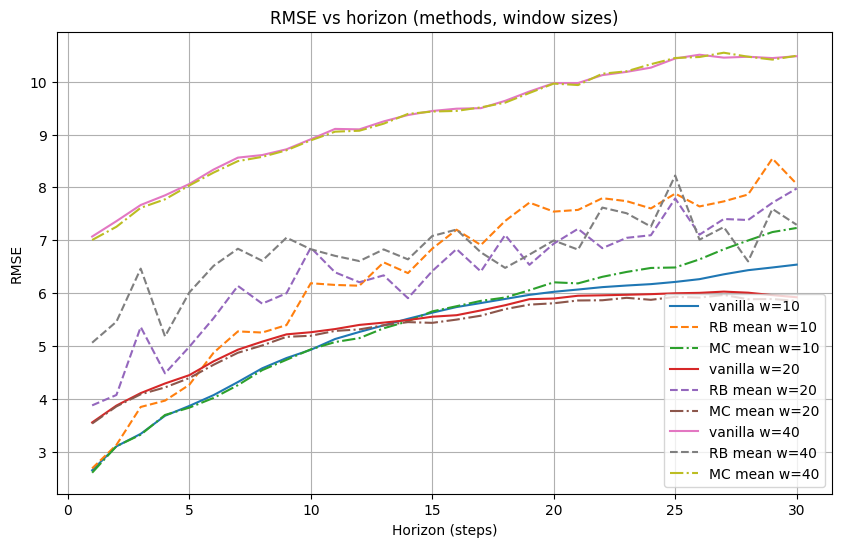

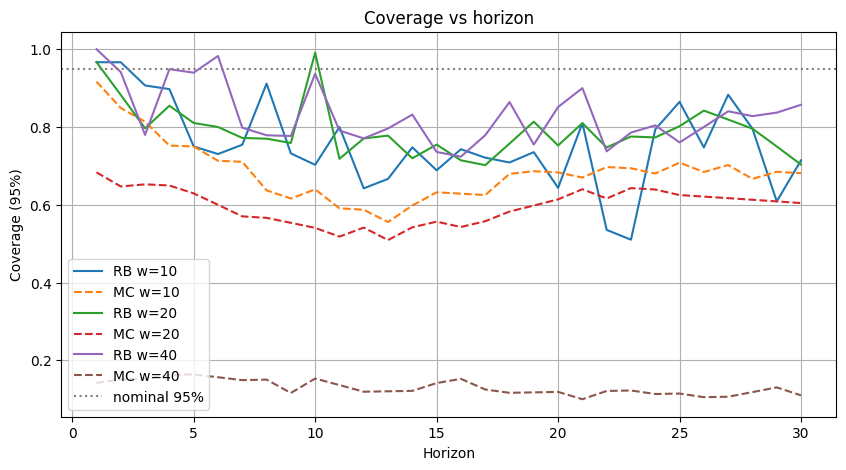

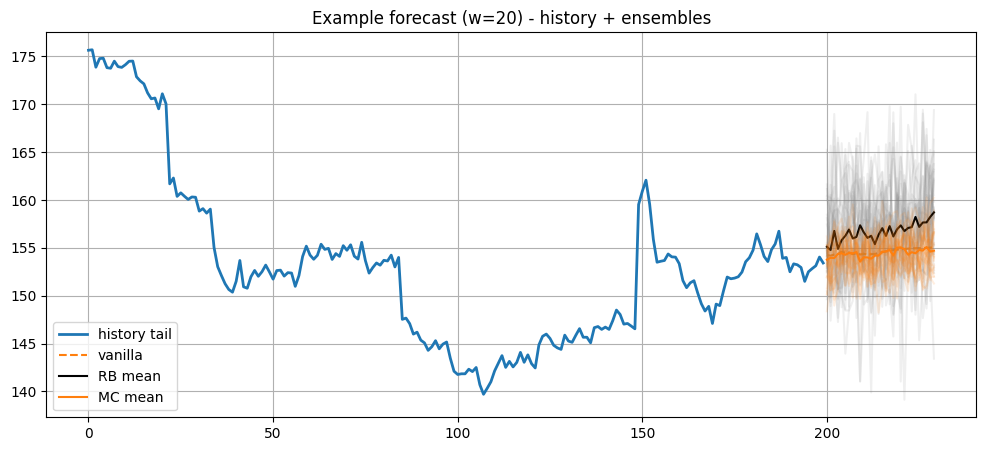

Ablation ranking

Triple labels ablation:
baseline macro-F1: 0.37058388887762916
  rsi: f1=0.2375  Δ=-0.1331
  close: f1=0.2695  Δ=-0.1011
  logret: f1=0.2875  Δ=-0.0831
  vol: f1=0.3148  Δ=-0.0558

Technical labels ablation:
baseline macro-F1: 0.48602530439765884
  rsi: f1=0.2774  Δ=-0.2086
  logret: f1=0.3917  Δ=-0.0944
  close: f1=0.4184  Δ=-0.0676
  vol: f1=0.4296  Δ=-0.0564
Window size & stride (empirical):
  - w=10: 1-step RMSE (vanilla) = 2.6446; mean 95% coverage RB=0.756, MC=0.684
  - w=20: 1-step RMSE (vanilla) = 3.5499; mean 95% coverage RB=0.790, MC=0.596
  - w=40: 1-step RMSE (vanilla) = 7.0693; mean 95% coverage RB=0.831, MC=0.130
Compare methods:
  For w=20, RMSE(1) vanilla=3.5499, RB=3.8732, MC=3.5297
  Coverage (mean across horizons, 95% interval): RB=0.790, MC=0.596
Labeling scheme effect on class balance and F1:
  - Triple labels distribution (full): sell 753 / hold 1413 / buy 834
  - Technical labels distribution (full): sell 596 / hold 1668 / buy 736


In [66]:
# Post-hoc experiments
warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize'] = (11,5)

WINDOW_CANDIDATES = [10, 20, 40]   
HORIZON = 30                        
EVAL_WINDOWS = 120                  
EPOCHS_REG = 30                     
RB_SAMPLES = 40                      
MC_SAMPLES = 40                      
GP_TRAIN_SUBSAMPLE = 1000           
RANDOM_SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)

if 'series' not in globals():
    raise RuntimeError("`series` not found. Run previous notebook cells to load stock series into variable `series`.")
series_arr = np.asarray(series, dtype=float)  # 1-D prices
n_total = len(series_arr)
print("Series length:", n_total)

class SmallMLP(nn.Module):
    def __init__(self, input_dim, hidden=[128,64], dropout=0.2):
        super().__init__()
        layers=[]
        prev=input_dim
        for h in hidden:
            layers += [nn.Linear(prev,h), nn.ReLU(), nn.Dropout(dropout)]
            prev=h
        layers += [nn.Linear(prev,1)]
        self.net = nn.Sequential(*layers)
    def forward(self,x):
        return self.net(x).view(-1)

def build_reg_windows(series, window_size, stride=1):
    X=[]; y=[]
    n=len(series)
    i=0
    while i + window_size < n:
        X.append(series[i:i+window_size].reshape(-1))
        y.append(series[i+window_size])
        i += stride
    return np.array(X), np.array(y)

def train_regressor(X_train, y_train, X_val, y_val, epochs=EPOCHS_REG, device=DEVICE):
    scaler_X = StandardScaler().fit(X_train)
    scaler_y = StandardScaler().fit(y_train.reshape(-1,1))
    Xt = scaler_X.transform(X_train)
    Xv = scaler_X.transform(X_val)
    yt = scaler_y.transform(y_train.reshape(-1,1)).reshape(-1)
    yv = scaler_y.transform(y_val.reshape(-1,1)).reshape(-1)
    model = SmallMLP(input_dim=Xt.shape[1], hidden=[128,64], dropout=0.2).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    batch = 64
    for ep in range(epochs):
        model.train()
        idx = np.arange(len(Xt))
        # don't shuffle (time-aware) but we can iterate sequentially
        for start in range(0, len(Xt), batch):
            end = start + batch
            xb = torch.tensor(Xt[start:end], dtype=torch.float32).to(device)
            yb = torch.tensor(yt[start:end], dtype=torch.float32).to(device)
            opt.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            loss.backward(); opt.step()
    # compute validation residuals (in original units)
    model.eval()
    with torch.no_grad():
        preds_val_scaled = model(torch.tensor(Xv, dtype=torch.float32).to(device)).cpu().numpy()
    preds_val = scaler_y.inverse_transform(preds_val_scaled.reshape(-1,1)).reshape(-1)
    residuals = (y_val - preds_val)
    return model, scaler_X, scaler_y, residuals

def recursive_vanilla(model, start_scaled, scaler_y, scaler_X, steps, device=DEVICE):
    # start_scaled is scaled X (shape d,) or raw X? We'll pass scaled_X here
    x = start_scaled.copy()
    preds = []
    model.eval()
    with torch.no_grad():
        for _ in range(steps):
            xb = torch.tensor(x.reshape(1,-1), dtype=torch.float32).to(device)
            out_scaled = model(xb).cpu().numpy().reshape(-1)[0]
            out_orig = scaler_y.inverse_transform(np.array([[out_scaled]])).reshape(-1)[0]
            preds.append(out_orig)
            # update x with scaled next input: need to convert out_orig back to scaled feature for next step
            # we assume X features are raw prices; so transform new window by replacing last val with out_orig then scale via scaler_X
            # but here x is scaled; easier alternative: maintain unscaled x_raw too
            # so we won't use this function; use version that works with unscaled window below
            raise RuntimeError("Use recursive_vanilla_from_raw (below) instead")
    return np.array(preds)

def recursive_vanilla_from_raw(model, window_raw, scaler_X, scaler_y, steps, device=DEVICE):
    # window_raw: raw prices (length window)
    x_raw = window_raw.copy()
    preds=[]
    model.eval()
    with torch.no_grad():
        for _ in range(steps):
            x_scaled = scaler_X.transform(x_raw.reshape(-1,1)).reshape(1,-1) if scaler_X.n_features_in_==1 else scaler_X.transform(x_raw.reshape(1,-1))
            xb = torch.tensor(x_scaled, dtype=torch.float32).to(device)
            out_scaled = model(xb).cpu().numpy().reshape(-1)[0]
            out_orig = scaler_y.inverse_transform(np.array([[out_scaled]])).reshape(-1)[0]
            preds.append(out_orig)
            # roll window in raw domain
            x_raw = np.roll(x_raw, -1); x_raw[-1] = out_orig
    return np.array(preds)

def residual_bootstrap_paths(model, window_raw, scaler_X, scaler_y, residuals, steps, n_paths=RB_SAMPLES, device=DEVICE):
    paths=[]
    rng = np.random.default_rng(RANDOM_SEED)
    for _ in range(n_paths):
        x_raw = window_raw.copy()
        path=[]
        for h in range(steps):
            x_scaled = scaler_X.transform(x_raw.reshape(1,-1))
            xb = torch.tensor(x_scaled, dtype=torch.float32).to(device)
            with torch.no_grad():
                out_scaled = model(xb).cpu().numpy().reshape(-1)[0]
            out_orig = scaler_y.inverse_transform(np.array([[out_scaled]])).reshape(-1)[0]
            sampled = rng.choice(residuals)
            noisy = out_orig + sampled
            path.append(noisy)
            x_raw = np.roll(x_raw, -1); x_raw[-1] = noisy
        paths.append(np.array(path))
    return np.stack(paths, axis=0)  # (n_paths, steps)

def mc_dropout_paths(model, window_raw, scaler_X, scaler_y, steps, n_paths=MC_SAMPLES, device=DEVICE):
    # enable dropout by model.train() temporarily
    paths=[]
    model.train()  # enable dropout
    for _ in range(n_paths):
        x_raw = window_raw.copy()
        path=[]
        for h in range(steps):
            x_scaled = scaler_X.transform(x_raw.reshape(1,-1))
            xb = torch.tensor(x_scaled, dtype=torch.float32).to(device)
            with torch.no_grad():
                out_scaled = model(xb).cpu().numpy().reshape(-1)[0]
            out_orig = scaler_y.inverse_transform(np.array([[out_scaled]])).reshape(-1)[0]
            path.append(out_orig)
            x_raw = np.roll(x_raw, -1); x_raw[-1] = out_orig
        paths.append(np.array(path))
    model.eval()
    return np.stack(paths, axis=0)

def safe_train_gp(X_windows_raw, y_next_raw, scaler_for_gp):
    # X_windows_raw shape (n, w), y_next_raw (n,)
    # scale (we'll use scaler_for_gp passed from earlier code or new one)
    X_scaled = scaler_for_gp.transform(X_windows_raw)
    y_scaled = scaler_for_gp.transform(y_next_raw.reshape(-1,1)).reshape(-1)
    # subsample for GP training
    n = len(X_scaled)
    idx = np.arange(n)
    if n > GP_TRAIN_SUBSAMPLE:
        rng = np.random.default_rng(RANDOM_SEED)
        idx = rng.choice(n, size=GP_TRAIN_SUBSAMPLE, replace=False)
    Xs = X_scaled[idx]; ys = y_scaled[idx]
    kernel = C(1.0, (1e-3,1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-3,1e3)) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-8, 1e1))
    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True, n_restarts_optimizer=2)
    try:
        gp.fit(Xs, ys)
    except Exception as e:
        print("GP training failed:", e)
        return None
    return gp

def gp_propagation_safe(gp, window_raw, scaler_X, scaler_y, steps):
    # This uses the gp_uncertainty_propagation_forecast if available; otherwise use gp.predict with increasing input cov
    # We'll do a simple approx: at each step, compute gp.predict(mean, return_std) and sample from Gaussian with clipped std
    x_raw = window_raw.copy()
    means=[]; stds=[]
    for _ in range(steps):
        x_scaled = scaler_X.transform(x_raw.reshape(1,-1))
        m, s = gp.predict(x_scaled, return_std=True)
        m = float(m[0]); s = float(s[0])
        # convert scaled to orig
        mean_orig = scaler_y.inverse_transform(np.array([[m]])).reshape(-1)[0]
        # convert scaled std to original: std_orig = s * y_std
        y_std = scaler_y.scale_[0] if hasattr(scaler_y, 'scale_') else 1.0
        std_orig = s * y_std
        # guard: cap std to reasonable max (e.g., 10 * historical std)
        hist_std = np.std(series_arr[-250:]) if len(series_arr)>250 else np.std(series_arr)
        max_std = max(1e-6, 10.0 * hist_std)
        if std_orig > max_std or not np.isfinite(std_orig):
            std_orig = max_std
        means.append(mean_orig); stds.append(std_orig)
        # use mean as next raw input
        x_raw = np.roll(x_raw, -1); x_raw[-1] = mean_orig
    return np.array(means), np.array(stds)

results_by_window = {}
for w in WINDOW_CANDIDATES:
    print("WINDOW SIZE:", w,"")
    X_all, y_all = build_reg_windows(series_arr, w, stride=STRIDE if 'STRIDE' in globals() else 1)
    # split 70/30 time-ordered
    n_windows = len(X_all)
    n_train = int(0.7 * n_windows)
    X_train = X_all[:n_train]; y_train = y_all[:n_train]
    X_val = X_all[n_train:]; y_val = y_all[n_train:]
    print("windows:", n_windows, "train/val:", X_train.shape[0], X_val.shape[0])

    # train regressor
    model, scaler_X, scaler_y, residuals = train_regressor(X_train, y_train, X_val, y_val, epochs=EPOCHS_REG, device=DEVICE)
    print("Trained regressor.")

    # choose evaluation starting windows: last EVAL_WINDOWS windows from validation set
    n_val = X_val.shape[0]
    eval_n = min(EVAL_WINDOWS, n_val - HORIZON - 1) if n_val > HORIZON else 0
    if eval_n <= 0:
        print("Not enough validation windows for horizon evaluation; skipping.")
        continue
    starts = np.arange(n_val - eval_n, n_val)  # indices relative to X_val
    # prepare per-method storage for mean predictions
    mean_pred_vanilla = np.full((eval_n, HORIZON), np.nan)
    mean_pred_rb = np.full((eval_n, HORIZON), np.nan)
    mean_pred_mc = np.full((eval_n, HORIZON), np.nan)
    ensemble_rb = np.zeros((eval_n, HORIZON, RB_SAMPLES))
    ensemble_mc = np.zeros((eval_n, HORIZON, MC_SAMPLES))

    # optional GP training on windows (use X_train,y_train raw arrays to build gp training)
    try:
        # reuse scaler_X / scaler_y for GP scaling
        gp = safe_train_gp(np.vstack([X_train, X_val]), np.concatenate([y_train, y_val]), scaler_y)  # note: scaling y with scaler_y (okay)
        if gp is None:
            print("GP not trained (safe_train_gp returned None). Will skip GP for this window size.")
    except Exception as e:
        print("GP training error:", e)
        gp = None

    # iterate eval starts
    for ii, idx in enumerate(starts):
        window_raw = X_val[idx].copy()
        last_obs_pos = (n_train + idx + w - 1)  # index in series
        # 1) vanilla
        try:
            preds_v = recursive_vanilla_from_raw(model, window_raw, scaler_X, scaler_y, HORIZON, device=DEVICE)
            mean_pred_vanilla[ii,:len(preds_v)] = preds_v
        except Exception as e:
            mean_pred_vanilla[ii,:] = np.nan
        # 2) RB
        try:
            rb = residual_bootstrap_paths(model, window_raw, scaler_X, scaler_y, residuals, HORIZON, n_paths=RB_SAMPLES, device=DEVICE)
            ensemble_rb[ii,:,:] = rb.T  # store as (H, S)
            mean_pred_rb[ii,:] = rb.mean(axis=0)
        except Exception as e:
            ensemble_rb[ii,:,:] = np.nan
            mean_pred_rb[ii,:] = np.nan
        # 3) MC Dropout
        try:
            mc = mc_dropout_paths(model, window_raw, scaler_X, scaler_y, HORIZON, n_paths=MC_SAMPLES, device=DEVICE)
            ensemble_mc[ii,:,:] = mc.T
            mean_pred_mc[ii,:] = mc.mean(axis=0)
        except Exception as e:
            ensemble_mc[ii,:,:] = np.nan
            mean_pred_mc[ii,:] = np.nan

    # ground truth extraction (for horizons where available)
    gt = np.full((eval_n, HORIZON), np.nan)
    for ii, idx in enumerate(starts):
        last_obs_pos = n_train + idx + w - 1
        for h in range(1, HORIZON+1):
            pos = last_obs_pos + h
            if pos < len(series_arr):
                gt[ii, h-1] = series_arr[pos]
            else:
                gt[ii, h-1] = np.nan

    # compute RMSE vs horizon for each method
    def compute_rmse_matrix(pred_matrix, gt_matrix):
        H = gt_matrix.shape[1]
        rms = []
        for h in range(H):
            mask = ~np.isnan(gt_matrix[:,h]) & ~np.isnan(pred_matrix[:,h])
            if mask.sum() == 0:
                rms.append(np.nan)
            else:
                rms.append(math.sqrt(mean_squared_error(gt_matrix[mask,h], pred_matrix[mask,h])))
        return np.array(rms)

    rmse_van = compute_rmse_matrix(mean_pred_vanilla, gt)
    rmse_rb = compute_rmse_matrix(mean_pred_rb, gt)
    rmse_mc = compute_rmse_matrix(mean_pred_mc, gt)

    # compute coverage for RB and MC across calib levels
    def coverage_from_ensemble(ensemble, gt, level=0.95):
        # ensemble shape: (eval_n, H, S); gt shape: (eval_n, H)
        lower_q = (1.0 - level) / 2.0
        upper_q = 1.0 - lower_q
        H = gt.shape[1]
        coverages=[]
        for h in range(H):
            covered=0; total=0
            for i in range(ensemble.shape[0]):
                if np.isnan(gt[i,h]): continue
                s = ensemble[i,h,:]
                if np.isnan(s).any(): continue
                lo = np.quantile(s, lower_q); hi = np.quantile(s, upper_q)
                if (gt[i,h] >= lo) and (gt[i,h] <= hi):
                    covered +=1
                total +=1
            coverages.append(covered/total if total>0 else np.nan)
        return np.array(coverages)

    cover_rb_95 = coverage_from_ensemble(ensemble_rb, gt, level=0.95)
    cover_mc_95 = coverage_from_ensemble(ensemble_mc, gt, level=0.95)

    # store results
    results_by_window[w] = {
        'rmse_vanilla': rmse_van,
        'rmse_rb': rmse_rb,
        'rmse_mc': rmse_mc,
        'cover_rb_95_mean': np.nanmean(cover_rb_95),
        'cover_mc_95_mean': np.nanmean(cover_mc_95),
        'ensemble_rb': ensemble_rb,
        'ensemble_mc': ensemble_mc,
        'gt': gt,
        'mean_pred_rb': mean_pred_rb,
        'mean_pred_mc': mean_pred_mc,
        'mean_pred_van': mean_pred_vanilla,
        'model': model, 'scaler_X': scaler_X, 'scaler_y': scaler_y, 'residuals': residuals, 'gp': gp
    }

    print(f"Window {w} RMSE(1) vanilla: {rmse_van[0]:.4f}, RB: {rmse_rb[0]:.4f}, MC: {rmse_mc[0]:.4f}")
    print(f"Window {w} 95% coverage mean across horizons -> RB: {results_by_window[w]['cover_rb_95_mean']:.3f}, MC: {results_by_window[w]['cover_mc_95_mean']:.3f}")

plt.figure(figsize=(10,6))
for w, res in results_by_window.items():
    h = np.arange(1, len(res['rmse_vanilla'])+1)
    plt.plot(h, res['rmse_vanilla'], label=f'vanilla w={w}', linestyle='-')
    plt.plot(h, res['rmse_rb'], label=f'RB mean w={w}', linestyle='--')
    plt.plot(h, res['rmse_mc'], label=f'MC mean w={w}', linestyle='-.')
plt.xlabel("Horizon (steps)"); plt.ylabel("RMSE"); plt.title("RMSE vs horizon (methods, window sizes)"); plt.legend(); plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
for w, res in results_by_window.items():
    # compute per-horizon coverage arrays for RB and MC
    cov_rb = coverage_from_ensemble(res['ensemble_rb'], res['gt'], level=0.95)
    cov_mc = coverage_from_ensemble(res['ensemble_mc'], res['gt'], level=0.95)
    plt.plot(np.arange(1, len(cov_rb)+1), cov_rb, label=f'RB w={w}')
    plt.plot(np.arange(1, len(cov_mc)+1), cov_mc, label=f'MC w={w}', linestyle='--')
plt.axhline(0.95, color='gray', linestyle=':', label='nominal 95%')
plt.xlabel("Horizon"); plt.ylabel("Coverage (95%)"); plt.title("Coverage vs horizon"); plt.legend(); plt.grid(True)
plt.show()

if 20 in results_by_window:
    res = results_by_window[20]
    # pick the last eval window index
    i = res['mean_pred_van'].shape[0]-1
    hist_tail = series_arr[-200:]  # last 200 observed
    # build future dates indices for plotting
    future_x = np.arange(len(hist_tail), len(hist_tail) + HORIZON)
    plt.figure(figsize=(12,5))
    plt.plot(np.arange(len(hist_tail)), hist_tail, label='history tail', linewidth=2)
    # vanilla
    plt.plot(future_x, res['mean_pred_van'][i], label='vanilla', linestyle='--')
    # RB ensemble
    for s in range(min(25, RB_SAMPLES)):
        plt.plot(future_x, res['ensemble_rb'][i,:,s], color='gray', alpha=0.12)
    plt.plot(future_x, res['mean_pred_rb'][i], label='RB mean', color='k', linewidth=1.5)
    # MC ensemble
    for s in range(min(25, MC_SAMPLES)):
        plt.plot(future_x, res['ensemble_mc'][i,:,s], color='tab:orange', alpha=0.12)
    plt.plot(future_x, res['mean_pred_mc'][i], label='MC mean', color='tab:orange', linewidth=1.5)
    plt.title("Example forecast (w=20) - history + ensembles")
    plt.legend(); plt.grid(True); plt.show()

# Ablation ranking
print("Ablation ranking")
# require feat_df, build_windows_from_features present
if 'feat_df' not in globals() or 'build_windows_from_features' not in globals():
    print("feat_df or helper function missing - skipping ablation ranking.")
else:
    cols = feat_df.columns.tolist()
    def run_ablation_label(X_seq_all, y_all, epochs=12):
        # train small LSTM (faster) with all features baseline and then drop each
        # returns baseline_f1 and dict of drop->f1
        from sklearn.preprocessing import StandardScaler
        n,w,f = X_seq_all.shape
        n_train = int(0.7*n)
        scaler = StandardScaler().fit(X_seq_all[:n_train].reshape(-1, f))
        Xs = scaler.transform(X_seq_all.reshape(-1, f)).reshape(n, w, f)
        train_X = Xs[:n_train]; train_y = y_all[:n_train]
        val_X = Xs[n_train:]; val_y = y_all[n_train:]
        # small LSTM
        class SmallLSTM(nn.Module):
            def __init__(self, input_size, hidden=32, ncls=3):
                super().__init__()
                self.lstm = nn.LSTM(input_size, hidden, batch_first=True)
                self.fc = nn.Linear(hidden, ncls)
            def forward(self,x):
                out,_ = self.lstm(x)
                return self.fc(out[:,-1,:])
        def train_and_eval(train_X, train_y, val_X, val_y, epochs=epochs):
            ds_tr = torch.utils.data.TensorDataset(torch.tensor(train_X,dtype=torch.float32), torch.tensor(train_y,dtype=torch.long))
            ds_val = torch.utils.data.TensorDataset(torch.tensor(val_X,dtype=torch.float32), torch.tensor(val_y,dtype=torch.long))
            loader_tr = torch.utils.data.DataLoader(ds_tr, batch_size=64, shuffle=False)
            loader_val = torch.utils.data.DataLoader(ds_val, batch_size=64, shuffle=False)
            # class weights
            from sklearn.utils.class_weight import compute_class_weight
            classes = np.unique(train_y)
            cw = compute_class_weight('balanced', classes=classes, y=train_y)
            weight_vector = np.ones(len(classes), dtype=np.float32)
            for i,c in enumerate(classes): weight_vector[c] = cw[i]
            w_tensor = torch.tensor(weight_vector).to(DEVICE)
            model = SmallLSTM(input_size=train_X.shape[2], hidden=32, ncls=len(np.unique(y_all))).to(DEVICE)
            opt = torch.optim.Adam(model.parameters(), lr=1e-3)
            loss_fn = nn.CrossEntropyLoss(weight=w_tensor)
            for ep in range(epochs):
                model.train()
                for xb,yb in loader_tr:
                    xb=xb.to(DEVICE); yb=yb.to(DEVICE)
                    opt.zero_grad(); out = model(xb); loss=loss_fn(out,yb); loss.backward(); opt.step()
            # eval
            ytrue=[]; ypred=[]
            model.eval()
            with torch.no_grad():
                for xb,yb in loader_val:
                    xb=xb.to(DEVICE)
                    out = model(xb)
                    preds = torch.argmax(out, dim=1).cpu().numpy()
                    ypred.extend(preds.tolist()); ytrue.extend(yb.numpy().tolist())
            from sklearn.metrics import f1_score
            return f1_score(np.array(ytrue), np.array(ypred), average='macro')
        base_f1 = train_and_eval(train_X, train_y, val_X, val_y)
        results = {}
        for ci, cname in enumerate(cols):
            X_mod = np.delete(X_seq_all, ci, axis=2)
            # re-split and train
            n_mod = X_mod.shape[0]
            ntr = int(0.7*n_mod)
            # scale inside train_and_eval uses first 70%
            f1_mod = train_and_eval(X_mod[:ntr], y_all[:ntr], X_mod[ntr:], y_all[ntr:])
            results[cname] = f1_mod
        return base_f1, results

    # run for both label sets if available
    if 'X_triple_seq' in globals() and 'y_triple' in globals():
        print("\nTriple labels ablation:")
        base_f1, res = run_ablation_label(X_triple_seq, y_triple, epochs=10)
        print("baseline macro-F1:", base_f1)
        # compute delta and ranking
        deltas = {c: res[c] - base_f1 for c in cols}
        rank = sorted(deltas.items(), key=lambda x: -abs(x[1]))  # by absolute change
        for c, d in rank:
            print(f"  {c}: f1={res[c]:.4f}  Δ={d:+.4f}")
    if 'X_tech_seq' in globals() and 'y_tech' in globals():
        print("\nTechnical labels ablation:")
        base_f1, res = run_ablation_label(X_tech_seq, y_tech, epochs=10)
        print("baseline macro-F1:", base_f1)
        deltas = {c: res[c] - base_f1 for c in cols}
        rank = sorted(deltas.items(), key=lambda x: -abs(x[1]))
        for c, d in rank:
            print(f"  {c}: f1={res[c]:.4f}  Δ={d:+.4f}")

# window size & stride
print("Window size & stride (empirical):")
for w, res in results_by_window.items():
    print(f"  - w={w}: 1-step RMSE (vanilla) = {res['rmse_vanilla'][0]:.4f}; mean 95% coverage RB={res['cover_rb_95_mean']:.3f}, MC={res['cover_mc_95_mean']:.3f}")

# compare methods (quantitative + qualitative)
print("Compare methods:")
# show chosen numbers for w=20
if 20 in results_by_window:
    r20 = results_by_window[20]
    print(f"  For w=20, RMSE(1) vanilla={r20['rmse_vanilla'][0]:.4f}, RB={r20['rmse_rb'][0]:.4f}, MC={r20['rmse_mc'][0]:.4f}")
    print(f"  Coverage (mean across horizons, 95% interval): RB={r20['cover_rb_95_mean']:.3f}, MC={r20['cover_mc_95_mean']:.3f}")
else:
    print("  Results for w=20 not available.")

# label balance & effect on F1
print("Labeling scheme effect on class balance and F1:")
print(f"  - Triple labels distribution (full): sell {np.bincount(y_triple)[0]} / hold {np.bincount(y_triple)[1]} / buy {np.bincount(y_triple)[2]}")
print(f"  - Technical labels distribution (full): sell {np.bincount(y_tech)[0]} / hold {np.bincount(y_tech)[1]} / buy {np.bincount(y_tech)[2]}")

Using WINDOW_SIZE = 20
Evaluating on 150 windows (last 150).


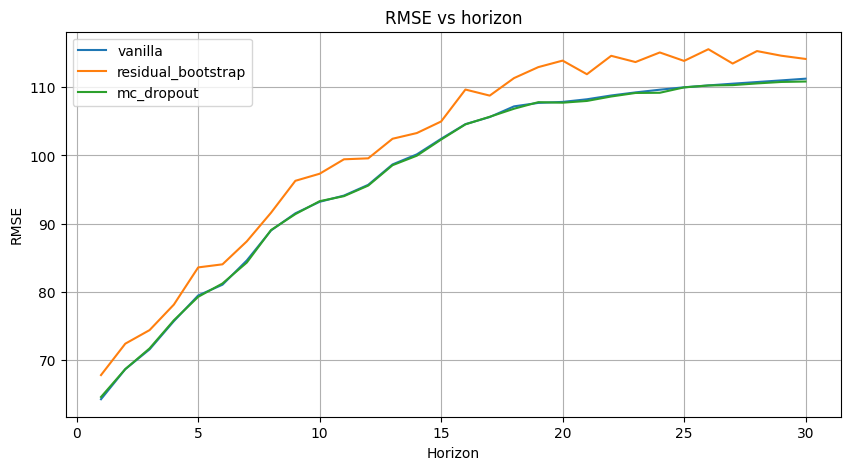


RMSE summary:
method                     h=1         h=5        h=10        h=20        h=30
vanilla                64.2227     79.4517     93.1997    107.8602    111.2666
residual_bootstrap     67.7656     83.5697     97.3179    113.9213    114.1662
mc_dropout             64.5498     79.2511     93.2913    107.7449    110.8539


In [67]:
# RMSE vs horizon evaluation

HORIZON = 30
N_EVAL = 150
MC_SAMPLES = 40
RB_SAMPLES = 40
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def warn(msg): print("[WARN]", msg)
def build_windows_from_series(series_arr, window_size):
    X=[]; idx=[]
    n=len(series_arr)
    i=0
    while i + window_size < n:
        X.append(series_arr[i:i+window_size].astype(float).copy())
        idx.append(i)
        i+=1
    return np.array(X), np.array(idx)

# series
if 'series' in globals() and series is not None:
    series_arr = np.asarray(series).reshape(-1)
elif 'series_arr' in globals() and series_arr is not None:
    series_arr = np.asarray(series_arr).reshape(-1)
elif 'df' in globals() and isinstance(df, (dict,))==False and 'Close' in df.columns:
    series_arr = df['Close'].values
else:
    raise RuntimeError("Could not find `series` / `series_arr` / df['Close'] in workspace. Please provide series.")

# model and scalers/residuals
reg_model = globals().get('model', globals().get('reg_model', None))
scaler_X = globals().get('scaler_X', globals().get('mlp_scaler', None))
scaler_y = globals().get('scaler_y', globals().get('value_scaler', globals().get('y_scaler', None)))
residuals = globals().get('residuals', None)
gp_obj = globals().get('gp', None)
gp_prop_func = globals().get('gp_uncertainty_propagation_forecast', None)

if 'WINDOW_SIZE' in globals() and WINDOW_SIZE is not None:
    WINDOW_SIZE_local = WINDOW_SIZE
else:
    # try infer from scaler_X if present
    if scaler_X is not None and hasattr(scaler_X, 'n_features_in_'):
        # If scaler_X was fit on flattened windows, try to guess window_size by dividing by number of feature columns available
        if 'feat_df' in globals():
            nfeat = globals()['feat_df'].shape[1]
            inferred = scaler_X.n_features_in_ // nfeat if (scaler_X.n_features_in_ % nfeat == 0) else None
            if inferred:
                WINDOW_SIZE_local = inferred
                warn(f"Inferring WINDOW_SIZE={WINDOW_SIZE_local} from scaler and feat_df n_features={nfeat}.")
            else:
                raise RuntimeError("WINDOW_SIZE not set and could not be inferred from scaler_X & feat_df. Set WINDOW_SIZE explicitly.")
        else:
            # if scaler was fit on single-series flattened windows, assume scaler.n_features_in_ is window size
            WINDOW_SIZE_local = scaler_X.n_features_in_
            warn(f"Inferring WINDOW_SIZE={WINDOW_SIZE_local} from scaler_X.n_features_in_.")
    else:
        raise RuntimeError("WINDOW_SIZE is not defined and cannot be inferred. Define WINDOW_SIZE and rerun.")

print("Using WINDOW_SIZE =", WINDOW_SIZE_local)

X_windows, starts = build_windows_from_series(series_arr, WINDOW_SIZE_local)
if len(X_windows) == 0:
    raise RuntimeError("No windows built. Check series length and WINDOW_SIZE.")
# We handle two major cases:
# 1) scaler_X expects exactly WINDOW_SIZE features -> single-series windows (close-only)
# 2) scaler_X expects WINDOW_SIZE * n_features -> flattened multi-feature windows. We build that using feat_df.
def construct_model_input_for_start(start_idx):
    """
    Return a 1D numpy array shaped to match scaler_X.n_features_in_ (or WINDOW_SIZE).
    start_idx is the index in the original series where the window starts (0-based).
    """
    # raw close-window
    raw_close = series_arr[start_idx:start_idx + WINDOW_SIZE_local].astype(float).copy()
    if scaler_X is None:
        # no scaler known -> return raw_close as default
        return raw_close.reshape(1,-1)
    # how many features was scaler_X fit on?
    if hasattr(scaler_X, 'n_features_in_'):
        req = scaler_X.n_features_in_
    else:
        # fallback: assume it expects WINDOW_SIZE
        req = WINDOW_SIZE_local
    # case single-series
    if req == WINDOW_SIZE_local:
        return raw_close.reshape(1,-1)
    # case flattened multi-feature windows
    if req % WINDOW_SIZE_local != 0:
        raise RuntimeError(f"Scaler expects {req} features which is not divisible by WINDOW_SIZE {WINDOW_SIZE_local}. Cannot construct input automatically.")
    n_feats_needed = req // WINDOW_SIZE_local
    if 'feat_df' not in globals():
        raise RuntimeError(f"Scaler expects flattened windows with {n_feats_needed} features per timestep but 'feat_df' not found. Provide feat_df or set scaler_X appropriate.")
    feat_vals = globals()['feat_df'].values
    # check bounds
    if start_idx + WINDOW_SIZE_local > feat_vals.shape[0]:
        raise RuntimeError("start index + WINDOW_SIZE exceeds feat_df length")
    if feat_vals.shape[1] < n_feats_needed:
        raise RuntimeError(f"feat_df has {feat_vals.shape[1]} feature columns but scaler expects {n_feats_needed}. Please align features used in training.")
    # select first n_feats_needed columns (assumes ordering matches the original training order)
    selected = feat_vals[start_idx:start_idx + WINDOW_SIZE_local, :n_feats_needed]
    return selected.reshape(1, -1)

def forecast_vanilla(start_idx, steps):
    if reg_model is None or scaler_X is None or scaler_y is None:
        raise RuntimeError("Vanilla forecast needs reg_model, scaler_X and scaler_y.")
    x_for_model = construct_model_input_for_start(start_idx)  # shape (1, req)
    # we will maintain raw arrays for rolling: for multi-feature input we will update only the last timestep features
    # to simplify: we keep a local "raw window" in the same format used to construct input for the start,
    # and after each prediction we append the predicted close into the underlying 'close' column (position 0)
    # Build two parallel arrays: close_window and feature_window (if multi-feature)
    close_window = series_arr[start_idx:start_idx + WINDOW_SIZE_local].copy()
    is_multi = scaler_X.n_features_in_ != WINDOW_SIZE_local
    if is_multi:
        feat_vals = globals()['feat_df'].values
        feature_window = feat_vals[start_idx:start_idx + WINDOW_SIZE_local, :scaler_X.n_features_in_//WINDOW_SIZE_local].copy()
    preds=[]
    reg_model.eval()
    with torch.no_grad():
        for _ in range(steps):
            # construct input for current window
            if is_multi:
                inp = feature_window.reshape(1, -1)
            else:
                inp = close_window.reshape(1, -1)
            # scale using scaler_X
            Xs = scaler_X.transform(inp)
            xb = torch.tensor(Xs, dtype=torch.float32).to(DEVICE)
            y_scaled = reg_model(xb).cpu().numpy().reshape(-1)[0]
            y_pred = scaler_y.inverse_transform(np.array([[y_scaled]])).reshape(-1)[0] if scaler_y is not None else y_scaled
            preds.append(y_pred)
            # roll windows: update close_window and feature_window (if multi) - assume feature columns are [close, logret, rsi, vol] ordering
            # update close_window raw
            close_window = np.roll(close_window, -1); close_window[-1] = y_pred
            # update feature_window if applicable: update first column (close) and recompute dependent columns if they exist
            if is_multi:
                # naive update: set first column (close) to new predicted close; recompute logret, rsi, vol using simplest approximations
                # For correctness: better to recompute from feat_df if you can access subsequent real rows. Here we do an approximate update:
                feature_window = np.roll(feature_window, -1, axis=0)
                # set last row's close
                feature_window[-1, 0] = y_pred
                # recompute logret = ln(close) - ln(prev_close)
                try:
                    prev_close = feature_window[-2, 0] if feature_window.shape[0] >= 2 else feature_window[-1,0]
                    feature_window[-1, 1] = np.log(max(y_pred,1e-8)) - np.log(max(prev_close,1e-8)) if feature_window.shape[1] > 1 else 0.0
                except Exception:
                    pass
                # we leave RSI and vol approx unchanged for simplicity; this is an approximation — it's better to use gp or explicit multi-step model if precise feature updates are needed.
    return np.array(preds)

def forecast_rb(start_idx, steps, n_paths=RB_SAMPLES):
    if residuals is None:
        raise RuntimeError("Residuals required for RB.")
    rng = np.random.default_rng(0)
    paths = np.zeros((n_paths, steps))
    for p in range(n_paths):
        # replicate vanilla but add sampled residual
        close_window = series_arr[start_idx:start_idx + WINDOW_SIZE_local].copy()
        is_multi = scaler_X.n_features_in_ != WINDOW_SIZE_local
        if is_multi:
            feat_vals = globals()['feat_df'].values
            feature_window = feat_vals[start_idx:start_idx + WINDOW_SIZE_local, :scaler_X.n_features_in_//WINDOW_SIZE_local].copy()
        for h in range(steps):
            if is_multi:
                inp = feature_window.reshape(1,-1)
            else:
                inp = close_window.reshape(1,-1)
            Xs = scaler_X.transform(inp)
            xb = torch.tensor(Xs, dtype=torch.float32).to(DEVICE)
            with torch.no_grad():
                y_scaled = reg_model(xb).cpu().numpy().reshape(-1)[0]
            y_pred = scaler_y.inverse_transform(np.array([[y_scaled]])).reshape(-1)[0] if scaler_y is not None else y_scaled
            samp = rng.choice(residuals)
            y_noisy = y_pred + samp
            paths[p,h] = y_noisy
            close_window = np.roll(close_window, -1); close_window[-1] = y_noisy
            if is_multi:
                feature_window = np.roll(feature_window, -1, axis=0)
                feature_window[-1,0] = y_noisy
    return paths

def forecast_mc(start_idx, steps, n_paths=MC_SAMPLES):
    paths = np.zeros((n_paths, steps))
    reg_model.train()  # enable dropout
    for p in range(n_paths):
        close_window = series_arr[start_idx:start_idx + WINDOW_SIZE_local].copy()
        is_multi = scaler_X.n_features_in_ != WINDOW_SIZE_local
        if is_multi:
            feat_vals = globals()['feat_df'].values
            feature_window = feat_vals[start_idx:start_idx + WINDOW_SIZE_local, :scaler_X.n_features_in_//WINDOW_SIZE_local].copy()
        for h in range(steps):
            if is_multi:
                inp = feature_window.reshape(1,-1)
            else:
                inp = close_window.reshape(1,-1)
            Xs = scaler_X.transform(inp)
            xb = torch.tensor(Xs, dtype=torch.float32).to(DEVICE)
            with torch.no_grad():
                y_scaled = reg_model(xb).cpu().numpy().reshape(-1)[0]
            y_pred = scaler_y.inverse_transform(np.array([[y_scaled]])).reshape(-1)[0] if scaler_y is not None else y_scaled
            paths[p,h] = y_pred
            close_window = np.roll(close_window, -1); close_window[-1] = y_pred
            if is_multi:
                feature_window = np.roll(feature_window, -1, axis=0)
                feature_window[-1,0] = y_pred
    reg_model.eval()
    return paths

valid_idx = []
for i, start_idx in enumerate(starts):
    last_obs = start_idx + WINDOW_SIZE_local - 1
    if last_obs + HORIZON < len(series_arr):
        valid_idx.append(i)
if len(valid_idx) == 0:
    raise RuntimeError("Not enough windows have HORIZON future points. Reduce HORIZON or use more data.")
sel = valid_idx[-N_EVAL:] if len(valid_idx) >= N_EVAL else valid_idx
eval_starts = starts[sel]
n_eval = len(eval_starts)
print(f"Evaluating on {n_eval} windows (last {n_eval}).")

pred_van = np.full((n_eval, HORIZON), np.nan)
pred_rb_mean = np.full((n_eval, HORIZON), np.nan)
pred_mc_mean = np.full((n_eval, HORIZON), np.nan)

for i, sidx in enumerate(eval_starts):
    try:
        if reg_model is not None:
            v = forecast_vanilla(sidx, HORIZON)
            pred_van[i,:len(v)] = v
    except Exception as e:
        warn(f"vanilla failed at start {sidx}: {e}")
    try:
        if residuals is not None:
            rb = forecast_rb(sidx, HORIZON, n_paths=RB_SAMPLES)
            pred_rb_mean[i,:] = rb.mean(axis=0)
    except Exception as e:
        warn(f"RB failed at start {sidx}: {e}")
    try:
        if reg_model is not None:
            mc = forecast_mc(sidx, HORIZON, n_paths=MC_SAMPLES)
            pred_mc_mean[i,:] = mc.mean(axis=0)
    except Exception as e:
        warn(f"MC failed at start {sidx}: {e}")

gt = np.full((n_eval, HORIZON), np.nan)
for ii, sidx in enumerate(eval_starts):
    last_obs = sidx + WINDOW_SIZE_local - 1
    for h in range(1, HORIZON+1):
        pos = last_obs + h
        if pos < len(series_arr):
            gt[ii, h-1] = series_arr[pos]

def horizon_rmse(preds, gt):
    H = preds.shape[1]
    rmse = []
    for h in range(H):
        mask = ~np.isnan(gt[:,h]) & ~np.isnan(preds[:,h])
        if mask.sum() == 0:
            rmse.append(np.nan)
        else:
            rmse.append(math.sqrt(mean_squared_error(gt[mask,h], preds[mask,h])))
    return np.array(rmse)

rmse = {}
if np.isfinite(pred_van).any():
    rmse['vanilla'] = horizon_rmse(pred_van, gt)
if np.isfinite(pred_rb_mean).any():
    rmse['residual_bootstrap'] = horizon_rmse(pred_rb_mean, gt)
if np.isfinite(pred_mc_mean).any():
    rmse['mc_dropout'] = horizon_rmse(pred_mc_mean, gt)

plt.figure(figsize=(10,5))
for name, arr in rmse.items():
    plt.plot(np.arange(1,len(arr)+1), arr, label=name)
plt.xlabel("Horizon"); plt.ylabel("RMSE"); plt.title("RMSE vs horizon"); plt.legend(); plt.grid(True); plt.show()

h_sel = [1,5,10,20,min(HORIZON,30)]
print("\nRMSE summary:")
header = ["method"] + [f"h={h}" for h in h_sel]
fmt = "{:<18}" + "{:>12}"*len(h_sel)
print(fmt.format(*header))
for name, arr in rmse.items():
    vals = [f"{arr[h-1]:.4f}" if not np.isnan(arr[h-1]) else "   NaN" for h in h_sel]
    print(fmt.format(name, *vals))